### **II. Read the Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
df = pd.read_csv('Loan_Approval_Final_8.csv')
df.head(10)

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,1/1/2018,45.0,39948.0,617.0,Employed,Master,22.0,13152.0,48.0,Married,...,3329.000000,0.724972,NaN,126928.0,0.199652,0.227590,419.805992,0.181077,0,49.0
1,1/2/2018,38.0,39709.0,628.0,Employed,Associate,15.0,NaN,48.0,Single,...,3309.083333,0.935132,3.0,43609.0,0.207045,0.201077,794.054238,0.389852,0,52.0
2,1/3/2018,47.0,40724.0,570.0,Employed,Bachelor,26.0,17627.0,NaN,Married,...,3393.666667,0.872241,6.0,NaN,0.217627,0.212548,NaN,0.462157,0,52.0
3,1/4/2018,58.0,69084.0,545.0,Employed,NaN,NaN,37898.0,96.0,NaN,...,5757.000000,0.896155,NaN,99452.0,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,1/5/2018,37.0,103264.0,594.0,Employed,Associate,17.0,NaN,36.0,Married,...,8605.333333,0.941369,NaN,227019.0,0.197184,0.175990,NaN,0.070210,0,36.0
5,1/6/2018,37.0,NaN,626.0,Self-Employed,Master,16.0,NaN,72.0,Married,...,14859.166670,0.756079,5.0,27071.0,0.217433,0.217601,NaN,0.075211,0,44.0
6,1/7/2018,58.0,51250.0,564.0,Employed,NaN,39.0,12741.0,48.0,Married,...,4270.833333,0.884275,NaN,NaN,0.225741,0.205271,391.300352,0.170529,0,50.0
7,1/8/2018,49.0,97345.0,516.0,Employed,High School,23.0,NaN,NaN,Divorced,...,NaN,0.933492,5.0,38621.0,0.226634,0.209113,1827.360055,0.260767,0,42.4
8,1/9/2018,34.0,116841.0,603.0,Employed,Bachelor,NaN,55353.0,60.0,NaN,...,9736.750000,0.728397,3.0,7711.0,0.258853,0.291539,1762.199026,0.246509,0,61.0
9,1/10/2018,46.0,NaN,NaN,Employed,Associate,19.0,25443.0,12.0,Married,...,3384.583333,0.615323,3.0,116812.0,0.184443,0.197271,2353.577424,0.903384,0,53.0


In [3]:
# Data shape
df.shape

(20000, 36)

In [4]:
# Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         17354 non-null  float64
 2   AnnualIncome                19208 non-null  float64
 3   CreditScore                 19603 non-null  float64
 4   EmploymentStatus            19532 non-null  object 
 5   EducationLevel              19492 non-null  object 
 6   Experience                  19696 non-null  float64
 7   LoanAmount                  19655 non-null  float64
 8   LoanDuration                19647 non-null  float64
 9   MaritalStatus               19619 non-null  object 
 10  NumberOfDependents          19397 non-null  float64
 11  HomeOwnershipStatus         19645 non-null  object 
 12  MonthlyDebtPayments         19402 non-null  float64
 13  CreditCardUtilizationRate   200

In [5]:
# Data Description
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,17354.000000,19208.000000,19603.000000,19696.000000,19655.000000,19647.000000,19397.000000,19402.000000,20000.000000,19677.000000,...,19412.000000,19990.000000,19664.000000,1.941600e+04,18055.000000,18432.000000,19573.000000,20000.000000,20000.000000,20000.000000
mean,39.731359,59184.733184,571.478498,17.507667,24854.018723,54.061994,1.515750,454.345274,0.286381,3.023733,...,4880.599071,0.799912,5.003865,7.233964e+04,0.239233,0.239075,910.854793,0.402182,0.082250,50.766780
std,11.616953,40400.782831,50.983147,11.319956,13386.142702,24.673621,1.385866,240.367010,0.159793,1.733428,...,3281.388115,0.120676,2.236008,1.184533e+05,0.035509,0.042280,671.331649,0.338924,0.274752,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31738.750000,540.000000,9.000000,15567.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2627.062500,0.727372,3.000000,8.734750e+03,0.214036,0.209081,493.606857,0.179693,0.000000,46.000000
50%,40.000000,48569.500000,578.000000,17.000000,21899.000000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4029.625000,0.820962,5.000000,3.284050e+04,0.236172,0.235392,728.476154,0.302711,0.000000,52.000000
75%,48.000000,74372.000000,609.000000,25.000000,30790.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6149.541667,0.892335,6.000000,8.852400e+04,0.261743,0.265605,1112.681913,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,9217.082609,4.647657,1.000000,84.000000


In [6]:
# Missing values
df.isnull().sum()

ApplicationDate                  0
Age                           2646
AnnualIncome                   792
CreditScore                    397
EmploymentStatus               468
EducationLevel                 508
Experience                     304
LoanAmount                     345
LoanDuration                   353
MaritalStatus                  381
NumberOfDependents             603
HomeOwnershipStatus            355
MonthlyDebtPayments            598
CreditCardUtilizationRate        0
NumberOfOpenCreditLines        323
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                    444
PreviousLoanDefaults             0
PaymentHistory                1025
LengthOfCreditHistory          452
SavingsAccountBalance          927
CheckingAccountBalance         697
TotalAssets                    734
TotalLiabilities               331
MonthlyIncome                  588
UtilityBillsPaymentHistory      10
JobTenure           

In [7]:
# Duplicated values
print(df.duplicated().sum())

0


              Count  Percentage
LoanApproved                   
0             18355       91.78
1              1645        8.22


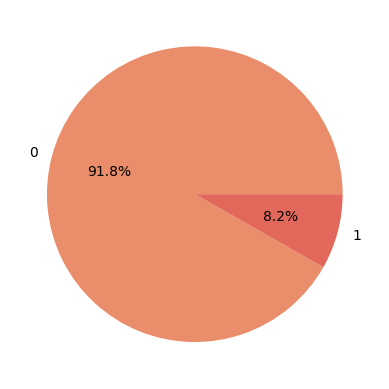

In [8]:
# Check for imbalance target variables
loan_counts = df['LoanApproved'].value_counts()
loan_percent = df['LoanApproved'].value_counts(normalize=True) * 100

class_dist = pd.DataFrame({
    'Count': loan_counts,
    'Percentage': loan_percent.round(2)
})

print(class_dist)

# Pie chart to visualize the percentage of statisfied and neutral_or_disatisfied category
plt.pie(df['LoanApproved'].value_counts(),
        labels = ["0", "1"],
        colors = sns.color_palette("flare"),
        autopct = '%1.1f%%')
plt.show()

### **III. Data Visualization**


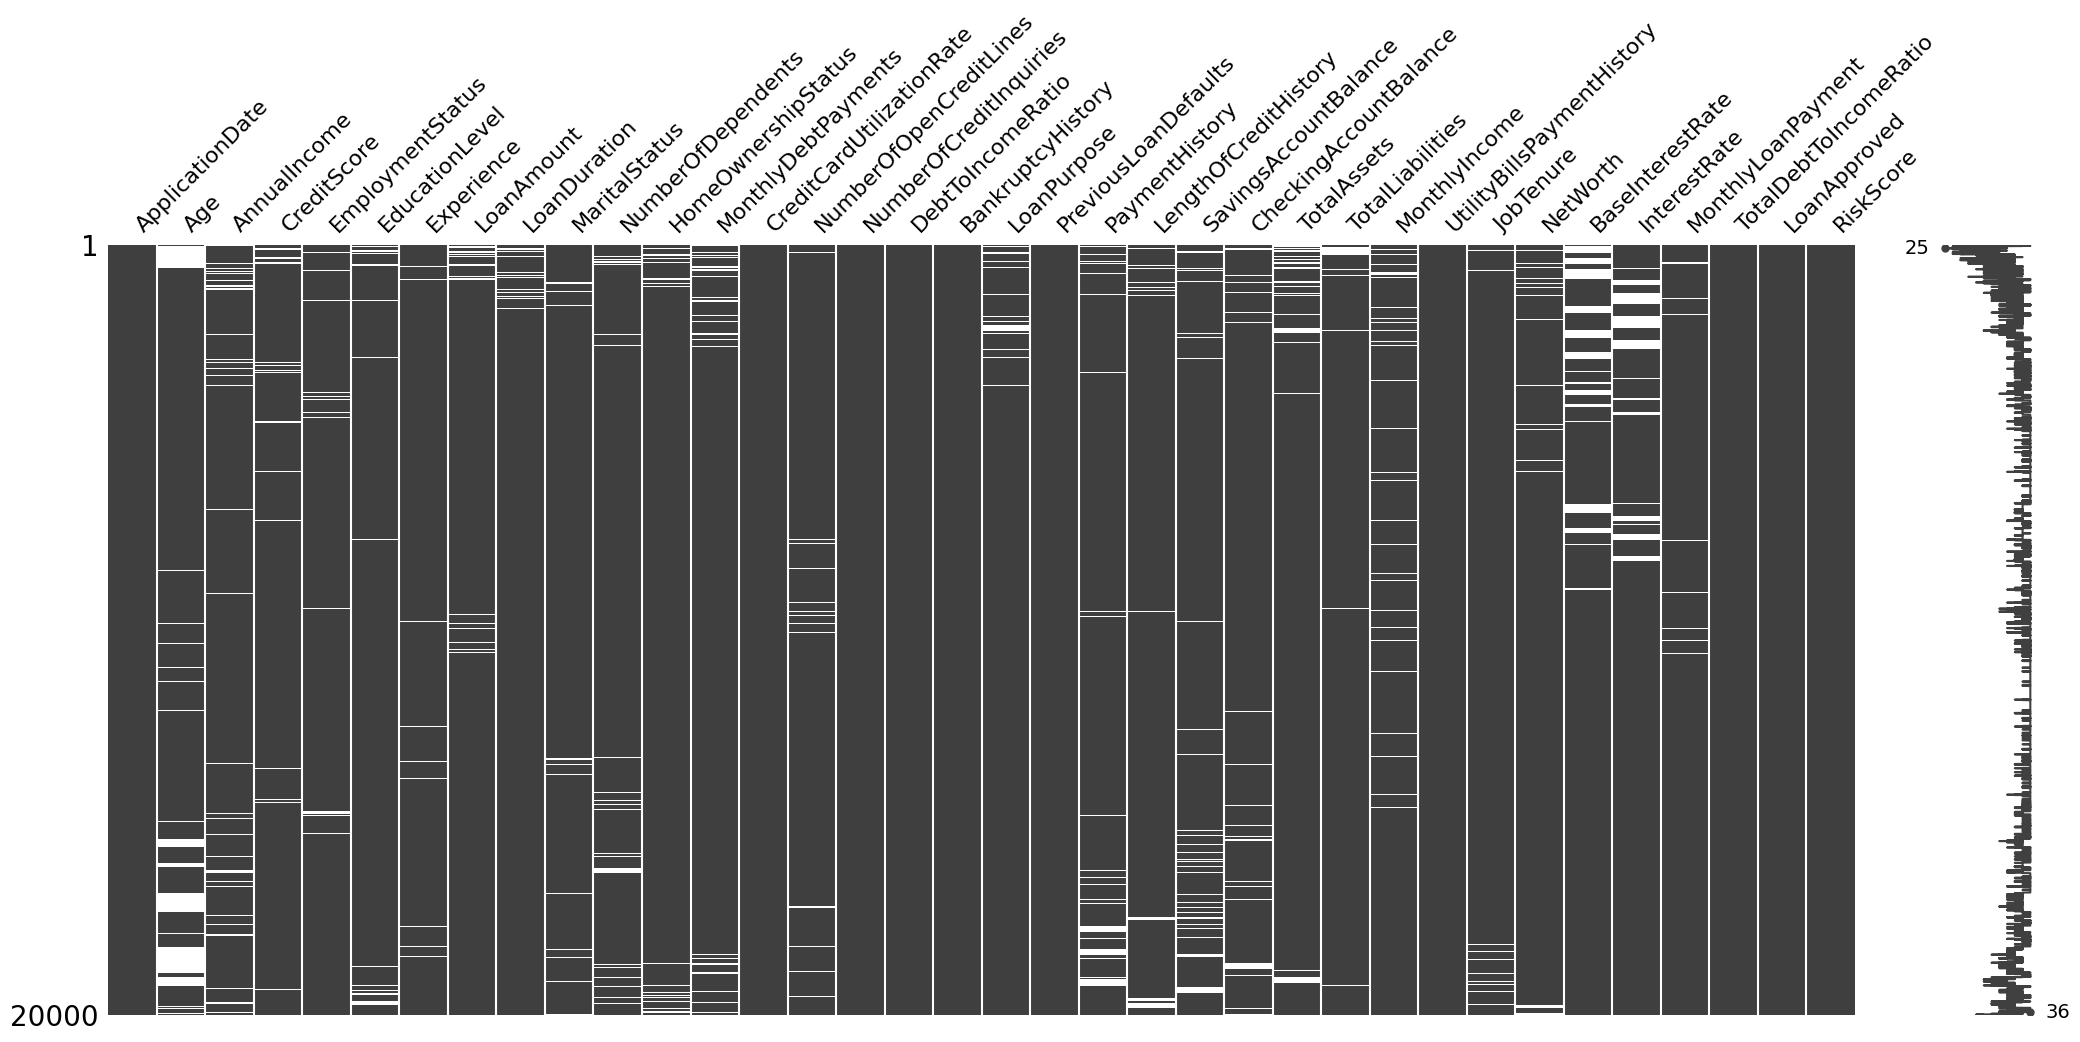

In [9]:
# Missingness Matrix plot: black = non-missing, white = missing
msno.matrix(df)
plt.show()

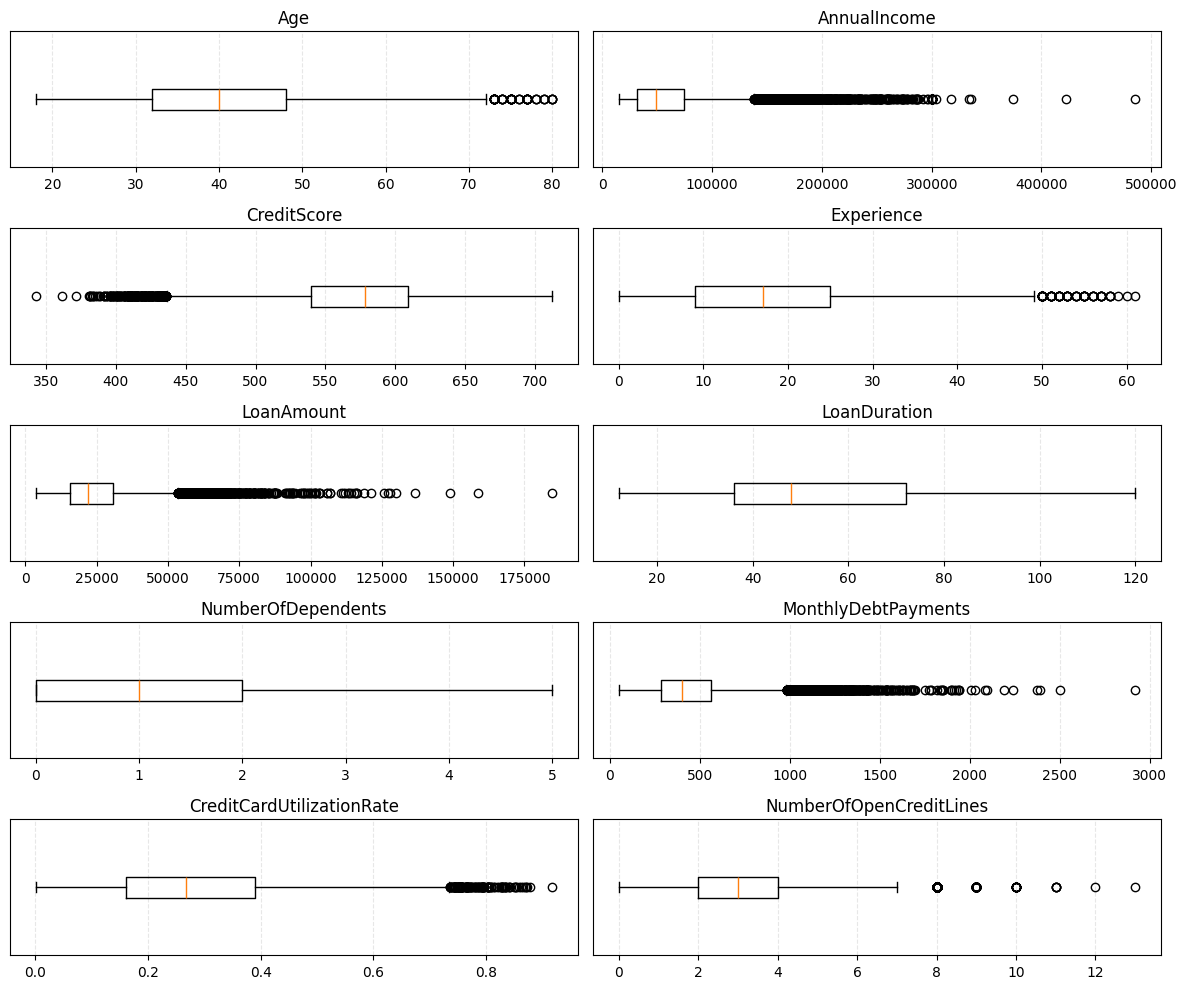

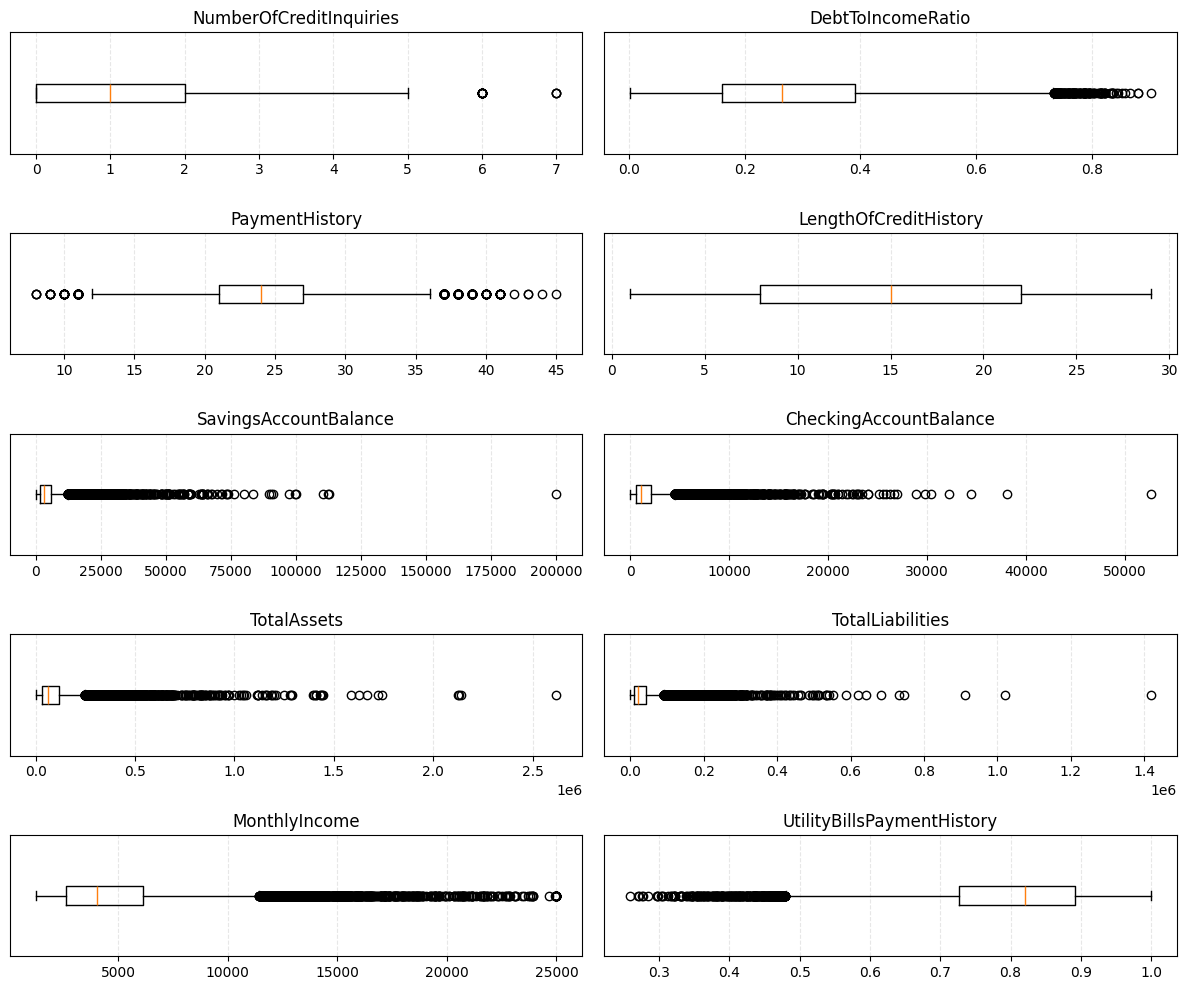

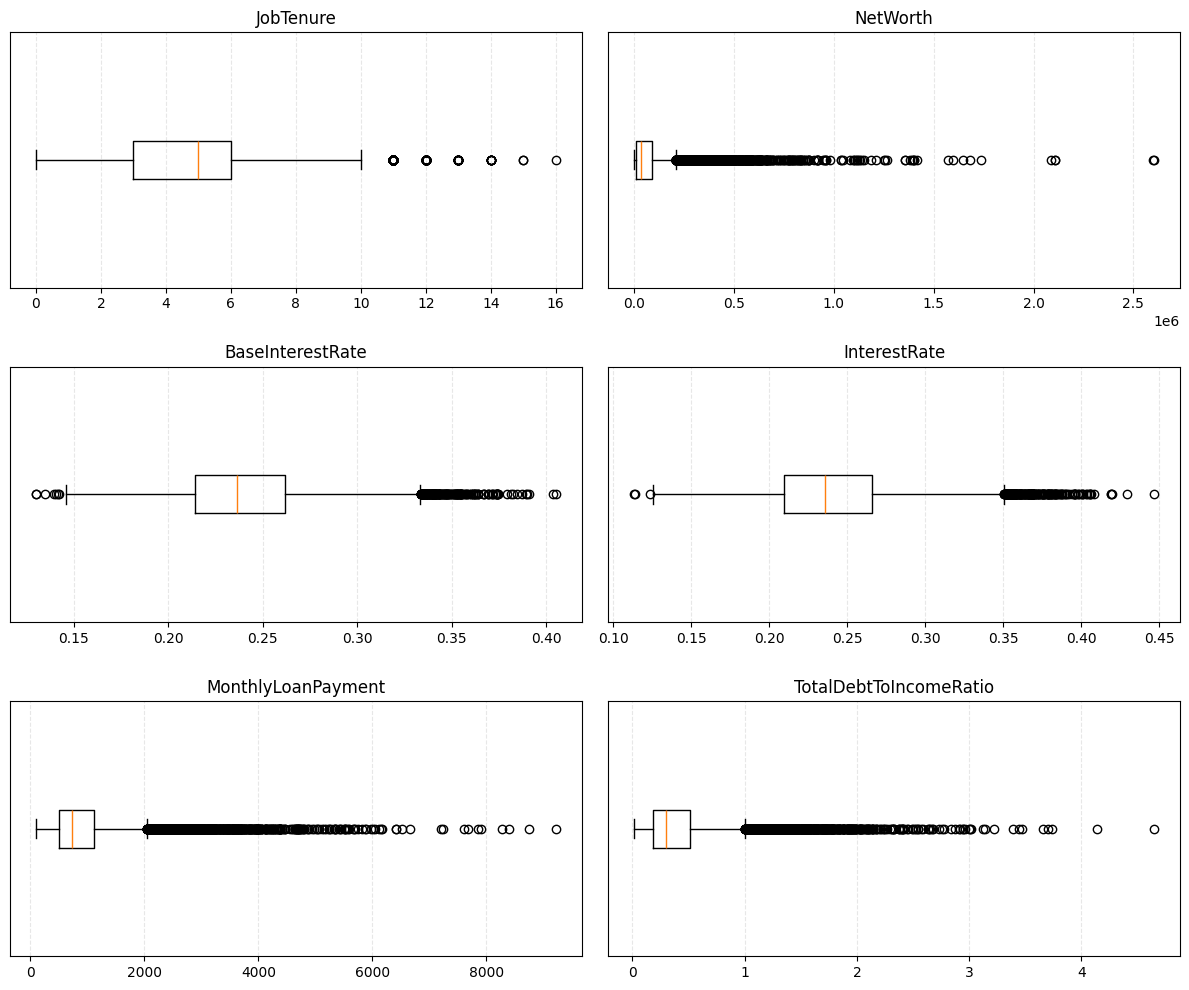

In [10]:
# Box-plot to visualize outliers
def boxplots_all_numeric(df, ncols=2, max_per_fig=10, figsize=(12, 10), exclude=None):
    import math
    import numpy as np
    import matplotlib.pyplot as plt

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if exclude:
        num_cols = [c for c in num_cols if c not in set(exclude)]
    for start in range(0, len(num_cols), max_per_fig):
        batch = num_cols[start:start+max_per_fig]
        nrows = math.ceil(len(batch) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
        for i, col in enumerate(batch):
            r, c = divmod(i, ncols)
            data = df[col].dropna().values
            axes[r, c].boxplot(data, vert=False, whis=1.5, showfliers=True)
            axes[r, c].set_title(col)
            axes[r, c].set_yticks([])
            axes[r, c].grid(axis='x', linestyle='--', alpha=0.3)
        # hide any unused panels
        for j in range(i+1, nrows*ncols):
            r, c = divmod(j, ncols)
            axes[r, c].set_visible(False)
        plt.tight_layout()
        plt.show()

# usage:
boxplots_all_numeric(df, ncols=2, max_per_fig=10, exclude=['LoanApproved', 'RiskScore', 'BankruptcyHistory', 'PreviousLoanDefaults'])

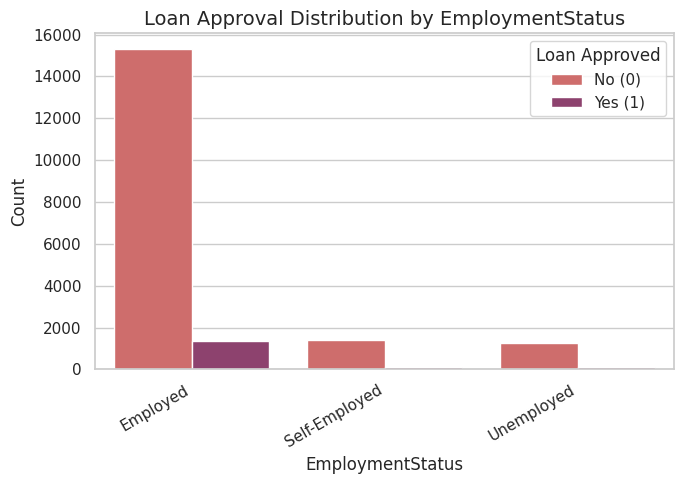

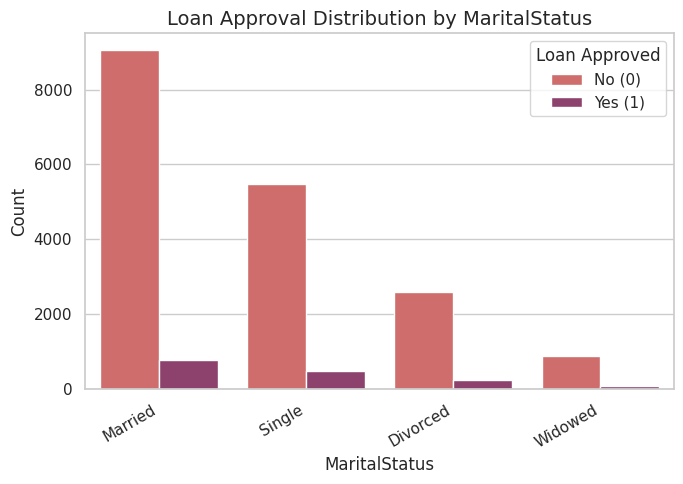

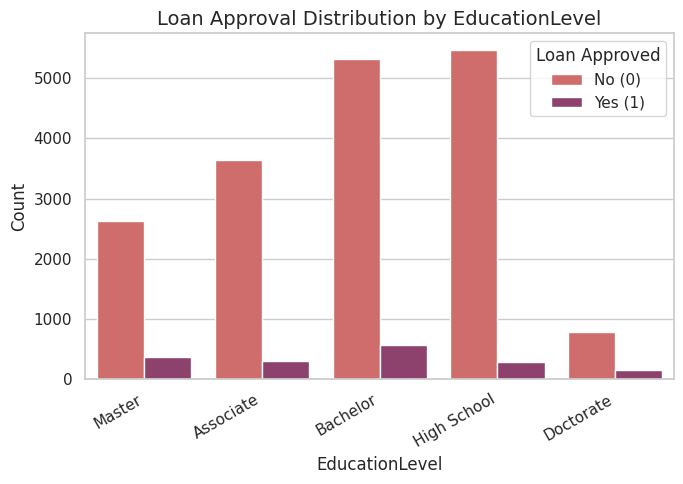

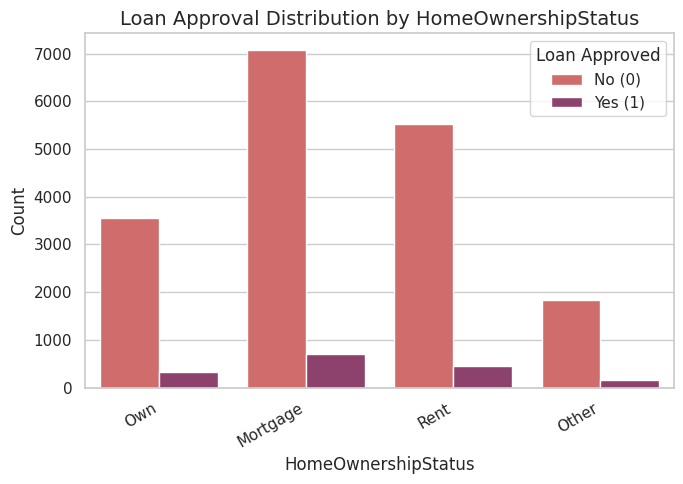

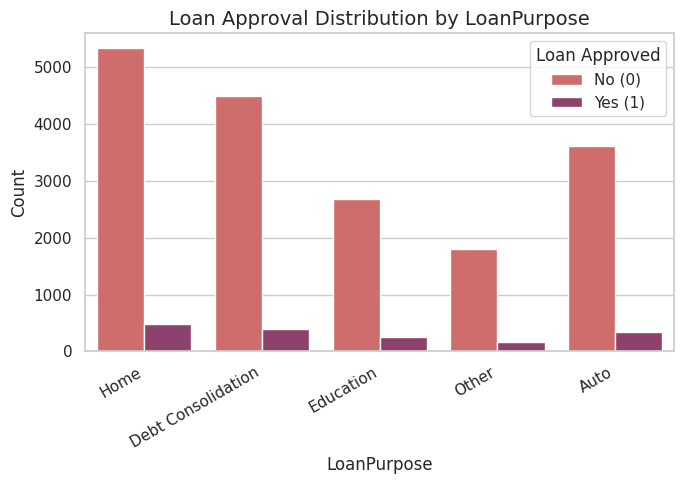

In [11]:
# Categorical Variable vs Target (LoanApproved) — Count Plot
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent visualization style
sns.set(style="whitegrid", palette="flare")

# Choose categorical columns to compare
categorical_features = ['EmploymentStatus', 'MaritalStatus', 'EducationLevel', 'HomeOwnershipStatus' , 'LoanPurpose']

# Plot count plots for each categorical feature vs LoanApproved
for feature in categorical_features:
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df, x=feature, hue='LoanApproved', palette="flare")
    plt.title(f'Loan Approval Distribution by {feature}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.legend(title='Loan Approved', labels=['No (0)', 'Yes (1)'])
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

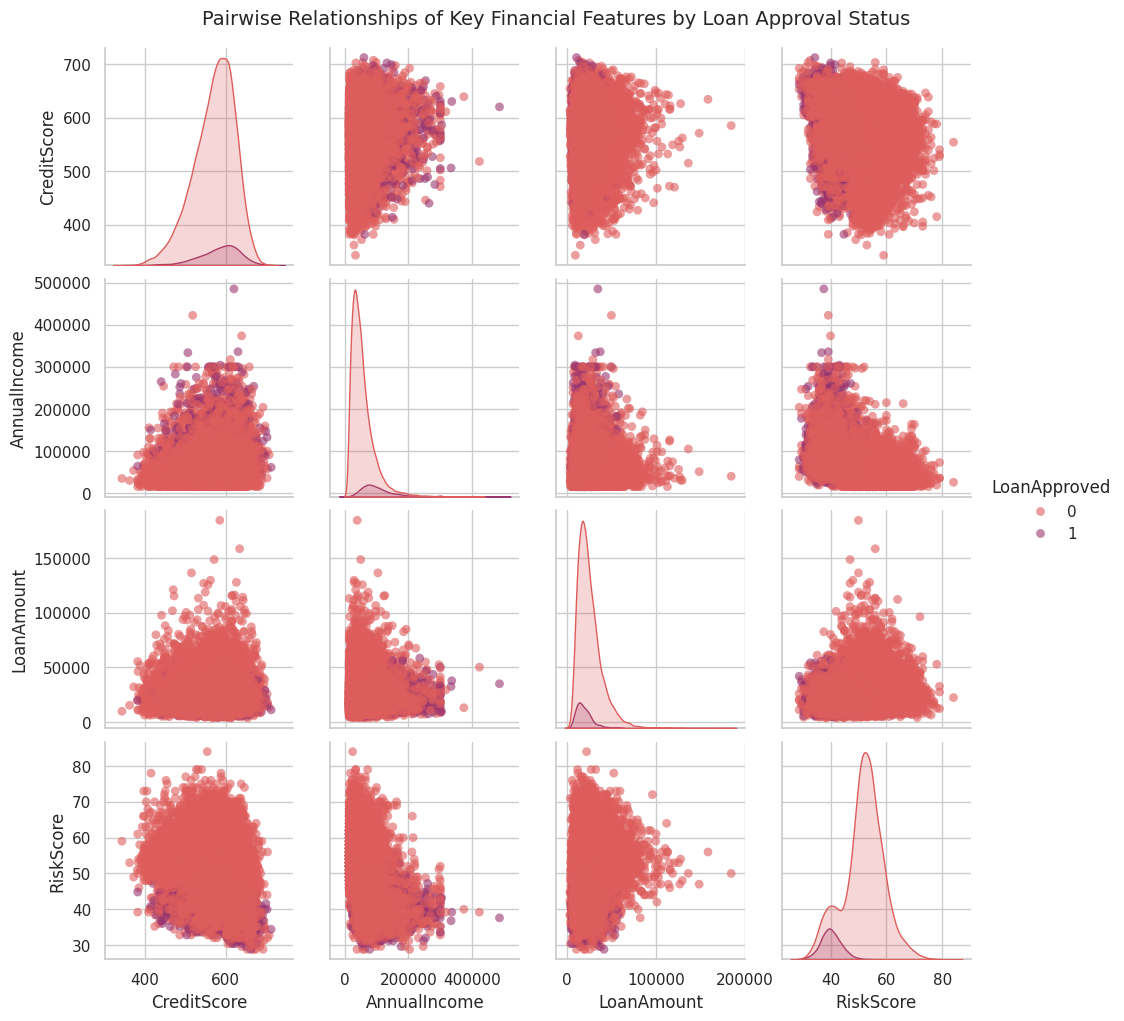

In [12]:
# Pairplot (Feature Relationships by Loan Status)
import seaborn as sns
import matplotlib.pyplot as plt

# Select top numerical features related to credit and loan profile
pairplot_features = [
    'CreditScore',
    'AnnualIncome',
    'LoanAmount',
    'RiskScore'
]

# Create the pairplot, color-coded by loan approval status
sns.pairplot(
    data=df,
    vars=pairplot_features,
    hue='LoanApproved',
    palette='flare',
    diag_kind='kde',
    plot_kws={'alpha':0.6, 's':40, 'edgecolor':'none'}
)

plt.suptitle('Pairwise Relationships of Key Financial Features by Loan Approval Status', fontsize=14, y=1.02)
plt.show()

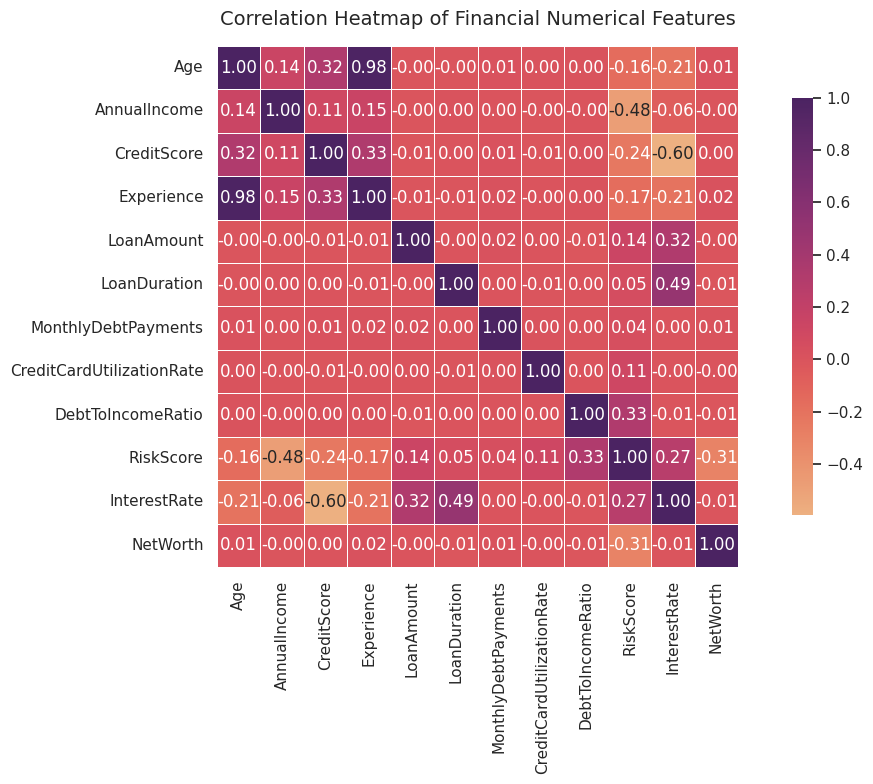

In [13]:
# Correlation Heatmap for Numerical Features
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns (excluding identifiers or dates)
num_cols = [
    'Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
    'LoanDuration', 'MonthlyDebtPayments', 'CreditCardUtilizationRate',
    'DebtToIncomeRatio', 'RiskScore', 'InterestRate', 'NetWorth'
]

# Compute the correlation matrix
corr = df[num_cols].corr()

# Set up the figure
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="flare",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    square=True
)
plt.title("Correlation Heatmap of Financial Numerical Features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### **IV.EDA & Basic Models Performance**

### **1. Handling Missing Values**

#### **a. Filling Median for Numerical and Mode for Categorical**

In [ ]:
# Identify numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# Fill missing values for numerical columns with median
for col in num_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

# Fill missing values for categorical columns with mode
for col in cat_cols:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

# Check remaining missing values
df.isnull().sum()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = df.drop('LoanApproved', axis = 1).select_dtypes(include = 'number')
y = df['LoanApproved']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

# Initializing models
lr = LogisticRegression(max_iter=200, random_state=42)
knn_classifier = KNeighborsClassifier()

# Train the models
lr.fit(X_train, y_train)
knn_classifier.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test)
y_pred_knn = knn_classifier.predict(X_test)

# Reports
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("K-Nearest Neighbors")
print(classification_report(y_test, y_pred_knn))

In [ ]:
# Confusion Matrix for Logistic Regression and KNN Classifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
ConfusionMatrixDisplay(cm_lr, display_labels=['Not Approved (0)', 'Approved (1)']).plot(
    cmap='Reds',
    ax=axes[0],
    values_format='d'
)
axes[0].set_title("Logistic Regression")

# KNN
ConfusionMatrixDisplay(cm_knn, display_labels=['Not Approved (0)', 'Approved (1)']).plot(
    cmap='Greens',
    ax=axes[1],
    values_format='d'
)
axes[1].set_title("KNN Classifier")

plt.tight_layout()
plt.show()

#### **b. KNN Imputation**

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Define X and y
X = df.drop('LoanApproved', axis=1).select_dtypes(include='number')
y = df['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Apply Standard Scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN Imputation
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

X_train_imputed = knn_imputer.fit_transform(X_train_scaled)
X_test_imputed = knn_imputer.transform(X_test_scaled)

# Train Models
lr = LogisticRegression(max_iter=500, random_state=42)
knn_classifier = KNeighborsClassifier(n_neighbors=5)

lr.fit(X_train_imputed, y_train)
knn_classifier.fit(X_train_imputed, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test_imputed)
y_pred_knn = knn_classifier.predict(X_test_imputed)

print("Logistic Regression (KNN Imputation)")
print(classification_report(y_test, y_pred_lr))

print("KNN Classifier (KNN Imputation)")
print(classification_report(y_test, y_pred_knn))

Logistic Regression (KNN Imputation)
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      3671
           1       0.26      0.07      0.11       329

    accuracy                           0.91      4000
   macro avg       0.59      0.52      0.53      4000
weighted avg       0.87      0.91      0.88      4000

KNN Classifier (KNN Imputation)
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3671
           1       0.37      0.16      0.22       329

    accuracy                           0.91      4000
   macro avg       0.65      0.57      0.59      4000
weighted avg       0.88      0.91      0.89      4000



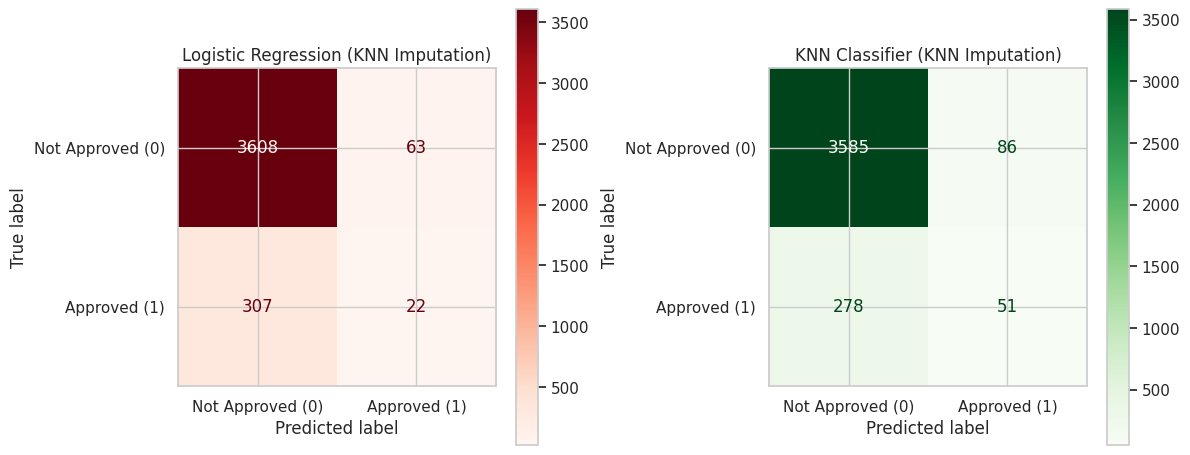

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=[0, 1])
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_lr, display_labels=['Not Approved (0)', 'Approved (1)']).plot(
    cmap='Reds', ax=axes[0], values_format='d'
)
axes[0].set_title("Logistic Regression (KNN Imputation)")

ConfusionMatrixDisplay(cm_knn, display_labels=['Not Approved (0)', 'Approved (1)']).plot(
    cmap='Greens', ax=axes[1], values_format='d'
)
axes[1].set_title("KNN Classifier (KNN Imputation)")

plt.tight_layout()
plt.show()

#### **c. Iterative Imputation**

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Define X and y
X = df.drop('LoanApproved', axis=1).select_dtypes(include='number')
y = df['LoanApproved']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Apply standard scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Iterative Imputation
iter_imputer = IterativeImputer(
    max_iter=10,
    random_state=42,
    sample_posterior=False
)

X_train_imputed = iter_imputer.fit_transform(X_train_scaled)
X_test_imputed = iter_imputer.transform(X_test_scaled)

# Train Models
lr = LogisticRegression(max_iter=500, random_state=42)
knn_classifier = KNeighborsClassifier(n_neighbors=5)

lr.fit(X_train_imputed, y_train)
knn_classifier.fit(X_train_imputed, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test_imputed)
y_pred_knn = knn_classifier.predict(X_test_imputed)

print("Logistic Regression (Iterative Imputation)")
print(classification_report(y_test, y_pred_lr))

print("KNN Classifier (Iterative Imputation)")
print(classification_report(y_test, y_pred_knn))

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=[0, 1])
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_lr, display_labels=['Not Approved (0)', 'Approved (1)']).plot(
    cmap='Reds', ax=axes[0], values_format='d'
)
axes[0].set_title("Logistic Regression (MICE)")

ConfusionMatrixDisplay(cm_knn, display_labels=['Not Approved (0)', 'Approved (1)']).plot(
    cmap='Greens', ax=axes[1], values_format='d'
)
axes[1].set_title("KNN Classifier (MICE)")

plt.tight_layout()
plt.show()

#### **d. Methods Comparison**

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report_lr_mm = classification_report(y_test, y_pred_lr, output_dict=True)
report_knn_mm = classification_report(y_test, y_pred_knn, output_dict=True)

report_lr_knn = classification_report(y_test, y_pred_lr, output_dict=True)
report_knn_knn = classification_report(y_test, y_pred_knn, output_dict=True)

report_lr_mice = classification_report(y_test, y_pred_lr, output_dict=True)
report_knn_mice = classification_report(y_test, y_pred_knn, output_dict=True)

In [ ]:
results_df = pd.DataFrame({
    'LR (Median/Mode)': {
        'Accuracy': report_lr_mm['accuracy'],
        'Precision': report_lr_mm['1']['precision'],
        'Recall': report_lr_mm['1']['recall'],
        'F1-score': report_lr_mm['1']['f1-score']
    },
    'KNN (Median/Mode)': {
        'Accuracy': report_knn_mm['accuracy'],
        'Precision': report_knn_mm['1']['precision'],
        'Recall': report_knn_mm['1']['recall'],
        'F1-score': report_knn_mm['1']['f1-score']
    },
    'LR (KNN Impute)': {
        'Accuracy': report_lr_knn['accuracy'],
        'Precision': report_lr_knn['1']['precision'],
        'Recall': report_lr_knn['1']['recall'],
        'F1-score': report_lr_knn['1']['f1-score']
    },
    'KNN (KNN Impute)': {
        'Accuracy': report_knn_knn['accuracy'],
        'Precision': report_knn_knn['1']['precision'],
        'Recall': report_knn_knn['1']['recall'],
        'F1-score': report_knn_knn['1']['f1-score']
    },
    'LR (MICE)': {
        'Accuracy': report_lr_mice['accuracy'],
        'Precision': report_lr_mice['1']['precision'],
        'Recall': report_lr_mice['1']['recall'],
        'F1-score': report_lr_mice['1']['f1-score']
    },
    'KNN (MICE)': {
        'Accuracy': report_knn_mice['accuracy'],
        'Precision': report_knn_mice['1']['precision'],
        'Recall': report_knn_mice['1']['recall'],
        'F1-score': report_knn_mice['1']['f1-score']
    }
})

results_df = results_df.round(3)
results_df

In [ ]:
import matplotlib.pyplot as plt

ax = results_df.T.plot(
    kind='bar',
    figsize=(12, 6),
    width=0.8
)

plt.title("Model Performance Comparison Across Imputation Methods", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Model & Imputation Method")
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **2. Handling Outliers**

#### **a. Winsorizing**

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 1) Define X and y (numeric only, like your modeling step)
X = df.drop('LoanApproved', axis=1).select_dtypes(include='number')
y = df['LoanApproved']

# 2) Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3) IQR-based capper (fit on train only)
def fit_iqr_caps(X_train_df, factor=1.5, exclude_cols=None):
    """
    Returns dict: {col: (lower_cap, upper_cap)} computed from X_train_df only.
    factor=1.5 is standard Tukey rule; increase to 3.0 to be less aggressive.
    """
    exclude_cols = set(exclude_cols or [])
    caps = {}

    for col in X_train_df.columns:
        if col in exclude_cols:
            continue

        s = X_train_df[col].dropna()
        if s.empty:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        # If IQR is 0 (almost constant column), skip capping
        if iqr == 0 or np.isnan(iqr):
            continue

        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        caps[col] = (lower, upper)

    return caps

def apply_caps(X_df, caps):
    """
    Clips columns using precomputed caps.
    """
    X_out = X_df.copy()
    for col, (lower, upper) in caps.items():
        X_out[col] = X_out[col].clip(lower=lower, upper=upper)
    return X_out

# Exclude binary / label-ish columns from outlier treatment
exclude_cols = [
    'BankruptcyHistory',
    'PreviousLoanDefaults',
    'CreditCardUtilizationRate',
    'DebtToIncomeRatio',
    'TotalDebtToIncomeRatio',
    'PaymentHistory',
    'UtilityBillsPaymentHistory',
    'RiskScore'
]

# 4) Fit caps on TRAIN, apply to BOTH train & test
iqr_caps = fit_iqr_caps(X_train, factor=1.5, exclude_cols=exclude_cols)
X_train_wins = apply_caps(X_train, iqr_caps)
X_test_wins  = apply_caps(X_test, iqr_caps)

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_wins)
X_test_scaled  = scaler.transform(X_test_wins)

# Impute
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
X_train_imputed = knn_imputer.fit_transform(X_train_scaled)
X_test_imputed  = knn_imputer.transform(X_test_scaled)

# Train models
lr = LogisticRegression(max_iter=500, random_state=42)
knn_classifier = KNeighborsClassifier(n_neighbors=5)

lr.fit(X_train_imputed, y_train)
knn_classifier.fit(X_train_imputed, y_train)

# Predict
y_pred_lr = lr.predict(X_test_imputed)
y_pred_knn = knn_classifier.predict(X_test_imputed)

print("Logistic Regression (Winsorize + Scale + KNN Impute)")
print(classification_report(y_test, y_pred_lr))

print("KNN Classifier (Winsorize + Scale + KNN Impute)")
print(classification_report(y_test, y_pred_knn))

Logistic Regression (Winsorize + Scale + KNN Impute)
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      3671
           1       0.30      0.08      0.13       329

    accuracy                           0.91      4000
   macro avg       0.61      0.53      0.54      4000
weighted avg       0.87      0.91      0.88      4000

KNN Classifier (Winsorize + Scale + KNN Impute)
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3671
           1       0.41      0.14      0.21       329

    accuracy                           0.91      4000
   macro avg       0.67      0.56      0.58      4000
weighted avg       0.89      0.91      0.89      4000



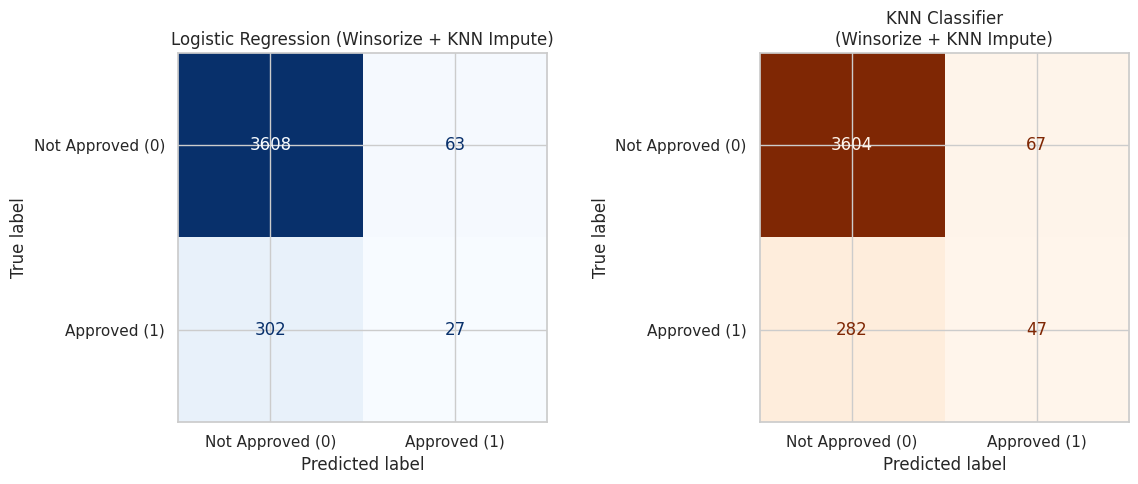

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=[0, 1])
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=[0, 1])

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression — Blue
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Blues',
    ax=axes[0],
    values_format='d',
    colorbar=False
)
axes[0].set_title("Logistic Regression (Winsorize + KNN Impute)")

# KNN Classifier — Orange
ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Oranges',
    ax=axes[1],
    values_format='d',
    colorbar=False
)
axes[1].set_title("KNN Classifier\n(Winsorize + KNN Impute)")

plt.tight_layout()
plt.show()

#### **b. Log Transformation**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

df_log = df.copy()

# Select Skewed Numerical Features
log_features = [
    'AnnualIncome',
    'LoanAmount',
    'MonthlyDebtPayments',
    'MonthlyLoanPayment',
    'NetWorth',
    'MonthlyIncome',
    'SavingsAccountBalance',
    'CheckingAccountBalance',
    'TotalAssets',
    'TotalLiabilities',
    'TotalDebtToIncomeRatio',
    'CreditCardUtilizationRate',
    'NumberOfOpenCreditLines'
]

# Apply Log1p Transformation
for col in log_features:
    df_log[col] = np.log1p(df_log[col])

# Visual Check (Before vs After)
for col in log_features:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.histplot(df[col], kde=True, ax=axes[0], color='orange')
    axes[0].set_title(f'Original {col}')

    sns.histplot(df_log[col], kde=True, ax=axes[1], color='blue')
    axes[1].set_title(f'Log-Transformed {col}')

    plt.tight_layout()
    plt.show()

In [ ]:
# X and y using Log-Transformed Data
X_log = df_log.drop('LoanApproved', axis=1).select_dtypes(include='number')
y = df_log['LoanApproved']

# Train/Test split
X_train_log, X_test_log, y_train, y_test = train_test_split(
    X_log, y, test_size=0.20, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

# Impute
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

X_train_imputed = knn_imputer.fit_transform(X_train_scaled)
X_test_imputed = knn_imputer.transform(X_test_scaled)

# Train models
lr_log = LogisticRegression(max_iter=500, random_state=42)
knn_log = KNeighborsClassifier(n_neighbors=5)

lr_log.fit(X_train_imputed, y_train)
knn_log.fit(X_train_imputed, y_train)

# Predict
y_pred_lr_log = lr_log.predict(X_test_imputed)
y_pred_knn_log = knn_log.predict(X_test_imputed)

# Classification Report
print("Logistic Regression (Log + KNN Imputation)")
print(classification_report(y_test, y_pred_lr_log))

print("KNN Classifier (Log + KNN Imputation)")
print(classification_report(y_test, y_pred_knn_log))

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrices
cm_lr_log = confusion_matrix(y_test, y_pred_lr_log, labels=[0, 1])
cm_knn_log = confusion_matrix(y_test, y_pred_knn_log, labels=[0, 1])

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression — Blue
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr_log,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Blues',
    ax=axes[0],
    values_format='d',
    colorbar=False
)
axes[0].set_title("Logistic Regression\n(Log-Transformation + KNN Impute)")

# KNN Classifier — Orange
ConfusionMatrixDisplay(
    confusion_matrix=cm_knn_log,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Oranges',
    ax=axes[1],
    values_format='d',
    colorbar=False
)
axes[1].set_title("KNN Classifier\n(Log-Transformation + KNN Impute)")

plt.tight_layout()
plt.show()

#### **c. Methods Comparison**

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report_lr_wins = classification_report(y_test, y_pred_lr, output_dict=True)
report_knn_wins = classification_report(y_test, y_pred_knn, output_dict=True)

report_lr_log = classification_report(y_test, y_pred_lr_log, output_dict=True)
report_knn_log = classification_report(y_test, y_pred_knn_log, output_dict=True)

In [ ]:
results_df = pd.DataFrame({
    'LR (Winsorizing + KNN Impute)': {
        'Accuracy': report_lr_wins['accuracy'],
        'Precision': report_lr_wins['1']['precision'],
        'Recall': report_lr_wins['1']['recall'],
        'F1-score': report_lr_wins['1']['f1-score']
    },
    'KNN (Winsorizing + KNN Impute)': {
        'Accuracy': report_knn_wins['accuracy'],
        'Precision': report_knn_wins['1']['precision'],
        'Recall': report_knn_wins['1']['recall'],
        'F1-score': report_knn_wins['1']['f1-score']
    },
    'LR (Log-Transformation + KNN Impute)': {
        'Accuracy': report_lr_log['accuracy'],
        'Precision': report_lr_log['1']['precision'],
        'Recall': report_lr_log['1']['recall'],
        'F1-score': report_lr_log['1']['f1-score']
    },
    'KNN (Log-Transformation + KNN Impute)': {
        'Accuracy': report_knn_log['accuracy'],
        'Precision': report_knn_log['1']['precision'],
        'Recall': report_knn_log['1']['recall'],
        'F1-score': report_knn_log['1']['f1-score']
    }
})

results_df = results_df.round(3)
results_df

In [ ]:
import matplotlib.pyplot as plt

ax = results_df.T.plot(
    kind='bar',
    figsize=(12, 6),
    width=0.8,
    color = ['#c7e9c0', '#a1d99b', '#74c476', '#238b45']
)

plt.title("Model Performance Comparison Across Handling Outliers/Imputation Methods", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Model & Handling Outliers/Imputation Method")
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **3. Handling Class Imbalance**

#### **a. SMOTE**

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Initialize SMOTE
smote = SMOTE(
    sampling_strategy='auto',  # balance both classes
    random_state=42,
    k_neighbors=5
)

# Apply SMOTE ONLY to training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_imputed, y_train
)

# Train models
lr_smote = LogisticRegression(max_iter=500, random_state=42)
knn_smote = KNeighborsClassifier(n_neighbors=5)

lr_smote.fit(X_train_smote, y_train_smote)
knn_smote.fit(X_train_smote, y_train_smote)

# Predict
y_pred_lr_smote = lr_smote.predict(X_test_imputed)
y_pred_knn_smote = knn_smote.predict(X_test_imputed)

print("Logistic Regression (Winsorize + KNN Impute + SMOTE)")
print(classification_report(y_test, y_pred_lr_smote))

print("KNN Classifier (Winsorize + KNN Impute + SMOTE)")
print(classification_report(y_test, y_pred_knn_smote))


Logistic Regression (Winsorize + KNN Impute + SMOTE)
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      3671
           1       0.35      0.98      0.52       329

    accuracy                           0.85      4000
   macro avg       0.67      0.91      0.71      4000
weighted avg       0.95      0.85      0.88      4000

KNN Classifier (Winsorize + KNN Impute + SMOTE)
              precision    recall  f1-score   support

           0       0.98      0.81      0.89      3671
           1       0.28      0.80      0.41       329

    accuracy                           0.81      4000
   macro avg       0.63      0.80      0.65      4000
weighted avg       0.92      0.81      0.85      4000



In [ ]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr_smote)
cm_knn = confusion_matrix(y_test, y_pred_knn_smote)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression — Blue
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Blues',
    ax=axes[0],
    values_format='d',
    colorbar=False
)
axes[0].set_title("Logistic Regression\n(Winsorize + KNN Impute + SMOTE)")

# KNN — Orange
ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Oranges',
    ax=axes[1],
    values_format='d',
    colorbar=False
)
axes[1].set_title("KNN Classifier\n(Winsorize + KNN Impute + SMOTE)")

plt.tight_layout()
plt.show()

#### **b. ADASYN**

In [26]:
from imblearn.over_sampling import ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize ADASYN
adasyn = ADASYN(
    sampling_strategy='auto',
    random_state=42,
    n_neighbors=5
)

# Apply ADASYN ONLY to training data
X_train_ada, y_train_ada = adasyn.fit_resample(
    X_train_imputed, y_train
)

# Train models
lr_ada = LogisticRegression(max_iter=500, random_state=42)
knn_ada = KNeighborsClassifier(n_neighbors=5)

lr_ada.fit(X_train_ada, y_train_ada)
knn_ada.fit(X_train_ada, y_train_ada)

# Predict on original (un-resampled) test set
y_pred_lr_ada = lr_ada.predict(X_test_imputed)
y_pred_knn_ada = knn_ada.predict(X_test_imputed)

print("Logistic Regression (Winsorize + KNN Impute + ADASYN)")
print(classification_report(y_test, y_pred_lr_ada))

print("KNN Classifier (Winsorize + KNN Impute + ADASYN)")
print(classification_report(y_test, y_pred_knn_ada))

Logistic Regression (Winsorize + KNN Impute + ADASYN)
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      3671
           1       0.35      0.99      0.52       329

    accuracy                           0.85      4000
   macro avg       0.68      0.91      0.72      4000
weighted avg       0.95      0.85      0.88      4000

KNN Classifier (Winsorize + KNN Impute + ADASYN)
              precision    recall  f1-score   support

           0       0.98      0.81      0.89      3671
           1       0.27      0.78      0.40       329

    accuracy                           0.81      4000
   macro avg       0.62      0.80      0.64      4000
weighted avg       0.92      0.81      0.85      4000



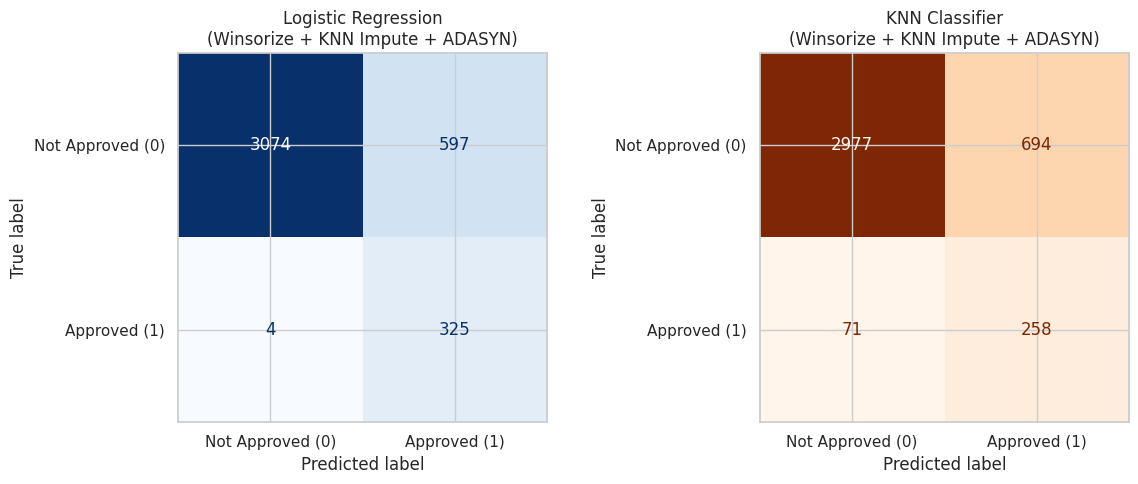

In [27]:
# Confusion Matrices
cm_lr_ada = confusion_matrix(y_test, y_pred_lr_ada)
cm_knn_ada = confusion_matrix(y_test, y_pred_knn_ada)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression — Blue
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr_ada,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Blues',
    ax=axes[0],
    values_format='d',
    colorbar=False
)
axes[0].set_title("Logistic Regression\n(Winsorize + KNN Impute + ADASYN)")

# KNN — Orange
ConfusionMatrixDisplay(
    confusion_matrix=cm_knn_ada,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Oranges',
    ax=axes[1],
    values_format='d',
    colorbar=False
)
axes[1].set_title("KNN Classifier\n(Winsorize + KNN Impute + ADASYN)")

plt.tight_layout()
plt.show()

#### **c. Random Undersampling**

In [19]:
from imblearn.under_sampling import RandomUnderSampler

# Initialize Random Undersampling
rus = RandomUnderSampler(random_state=42)

# Apply RUS ONLY to training data
X_train_rus, y_train_rus = rus.fit_resample(
    X_train_imputed, y_train
)

# Train only with Logistic Regression
lr_rus = LogisticRegression(max_iter=500, random_state=42)
lr_rus.fit(X_train_rus, y_train_rus)

# Predict
y_pred_lr_rus = lr_rus.predict(X_test_imputed)

# Classification Report
print("Logistic Regression (Winsorize + KNN Impute + Random Undersampling)")
print(classification_report(y_test, y_pred_lr_rus))

Logistic Regression (Winsorize + KNN Impute + Random Undersampling)
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      3671
           1       0.35      0.98      0.52       329

    accuracy                           0.85      4000
   macro avg       0.67      0.91      0.71      4000
weighted avg       0.94      0.85      0.88      4000



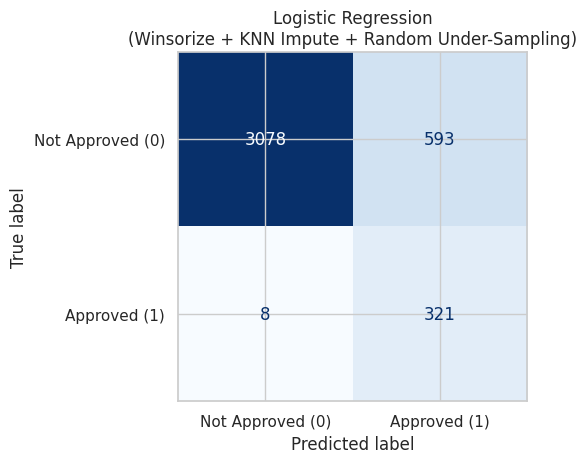

In [20]:
# Confusion Matrix
cm_lr_rus = confusion_matrix(y_test, y_pred_lr_rus)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr_rus,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Blues',
    values_format='d',
    colorbar=False
)

plt.title("Logistic Regression\n(Winsorize + KNN Impute + Random Under-Sampling)")
plt.tight_layout()
plt.show()

#### **d. SMOTE + ENN**

In [ ]:
from imblearn.combine import SMOTEENN

# Initialize SMOTE + ENN
smote_enn = SMOTEENN(random_state=42)

# Apply SMOTEENN ONLY to training data
X_train_se, y_train_se = smote_enn.fit_resample(
    X_train_imputed, y_train
)

# Train models
lr_se = LogisticRegression(max_iter=500, random_state=42)
knn_se = KNeighborsClassifier(n_neighbors=5)

lr_se.fit(X_train_se, y_train_se)
knn_se.fit(X_train_se, y_train_se)

# Predict on original test set
y_pred_lr_se = lr_se.predict(X_test_imputed)
y_pred_knn_se = knn_se.predict(X_test_imputed)

print("Logistic Regression (Winsorize + KNN Impute + SMOTE + ENN)")
print(classification_report(y_test, y_pred_lr_se))

print("KNN Classifier (Winsorize + KNN Impute + SMOTE + ENN)")
print(classification_report(y_test, y_pred_knn_se))

Logistic Regression (Winsorize + KNN Impute + SMOTE + ENN)
              precision    recall  f1-score   support

           0       1.00      0.83      0.91      3671
           1       0.35      1.00      0.52       329

    accuracy                           0.85      4000
   macro avg       0.68      0.92      0.71      4000
weighted avg       0.95      0.85      0.88      4000

KNN Classifier (Winsorize + KNN Impute + SMOTE + ENN)
              precision    recall  f1-score   support

           0       0.99      0.77      0.87      3671
           1       0.27      0.95      0.42       329

    accuracy                           0.79      4000
   macro avg       0.63      0.86      0.65      4000
weighted avg       0.93      0.79      0.83      4000



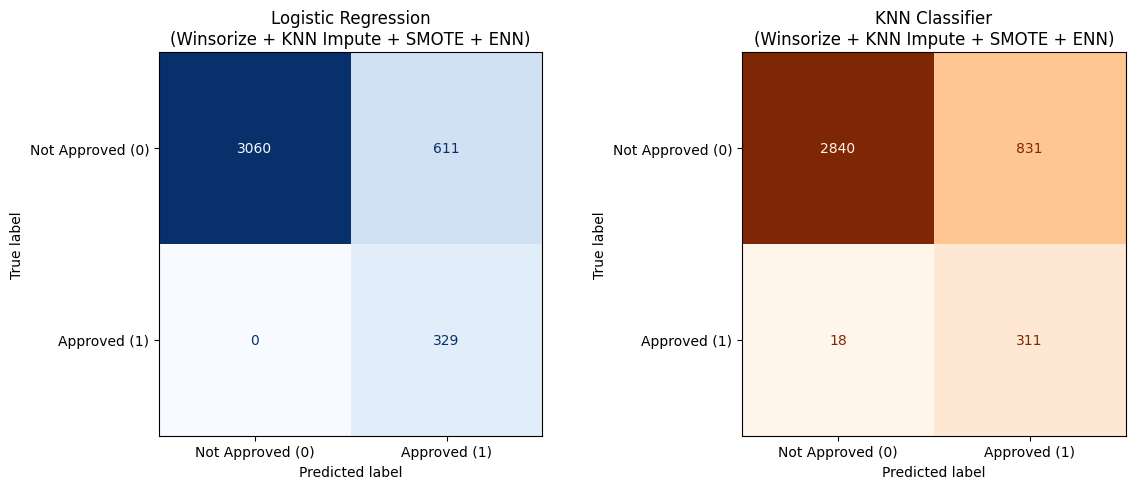

In [ ]:
# Confusion Matrices
cm_lr_se = confusion_matrix(y_test, y_pred_lr_se)
cm_knn_se = confusion_matrix(y_test, y_pred_knn_se)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression — Blue
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr_se,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Blues',
    ax=axes[0],
    values_format='d',
    colorbar=False
)
axes[0].set_title("Logistic Regression\n(Winsorize + KNN Impute + SMOTE + ENN)")

# KNN — Orange
ConfusionMatrixDisplay(
    confusion_matrix=cm_knn_se,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Oranges',
    ax=axes[1],
    values_format='d',
    colorbar=False
)
axes[1].set_title("KNN Classifier\n(Winsorize + KNN Impute + SMOTE + ENN)")

plt.tight_layout()
plt.show()

#### **e. Methods Comparison**

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report_lr_smote = classification_report(y_test, y_pred_lr_smote, output_dict = True)
report_knn_smote = classification_report(y_test, y_pred_knn_smote, output_dict = True)

report_lr_ada = classification_report(y_test, y_pred_lr_ada, output_dict = True)
report_knn_ada = classification_report(y_test, y_pred_knn_ada, output_dict = True)

report_lr_se = classification_report(y_test, y_pred_lr_se, output_dict = True)
report_knn_se = classification_report(y_test, y_pred_knn_se, output_dict = True)

In [ ]:
results_df = pd.DataFrame({
    'LR (Winsorizing + KNN Impute + SMOTE)': {
        'Accuracy': report_lr_smote['accuracy'],
        'Precision': report_lr_smote['1']['precision'],
        'Recall': report_lr_smote['1']['recall'],
        'F1-score': report_lr_smote['1']['f1-score']
    },
    'KNN (Winsorizing + KNN Impute + SMOTE)': {
        'Accuracy': report_knn_smote['accuracy'],
        'Precision': report_knn_smote['1']['precision'],
        'Recall': report_knn_smote['1']['recall'],
        'F1-score': report_knn_smote['1']['f1-score']
    },
    'LR (Winsorizing + KNN Impute + ADASYN)': {
        'Accuracy': report_lr_ada['accuracy'],
        'Precision': report_lr_ada['1']['precision'],
        'Recall': report_lr_ada['1']['recall'],
        'F1-score': report_lr_ada['1']['f1-score']
    },
    'KNN (Winsorizing + KNN Impute + ADASYN)': {
        'Accuracy': report_knn_ada['accuracy'],
        'Precision': report_knn_ada['1']['precision'],
        'Recall': report_knn_ada['1']['recall'],
        'F1-score': report_knn_ada['1']['f1-score']
    },
     'LR (Winsorizing + KNN Impute + SMOTE/ENN)': {
        'Accuracy': report_lr_se['accuracy'],
        'Precision': report_lr_se['1']['precision'],
        'Recall': report_lr_se['1']['recall'],
        'F1-score': report_lr_se['1']['f1-score']
    },
    'KNN (Winsorizing + KNN Impute + SMOTE/ENN)': {
        'Accuracy': report_knn_se['accuracy'],
        'Precision': report_knn_se['1']['precision'],
        'Recall': report_knn_se['1']['recall'],
        'F1-score': report_knn_se['1']['f1-score']
    }
})

results_df = results_df.round(3)
results_df

,LR (Winsorizing + KNN Impute + SMOTE),KNN (Winsorizing + KNN Impute + SMOTE),LR (Winsorizing + KNN Impute + ADASYN),KNN (Winsorizing + KNN Impute + ADASYN),LR (Winsorizing + KNN Impute + SMOTE/ENN),KNN (Winsorizing + KNN Impute + SMOTE/ENN)
Accuracy,0.849,0.812,0.850,0.809,0.847,0.788
Precision,0.351,0.276,0.352,0.271,0.350,0.272
Recall,0.985,0.796,0.988,0.784,1.000,0.945
F1-score,0.518,0.410,0.520,0.403,0.519,0.423


In [ ]:
import matplotlib.pyplot as plt

ax = results_df.T.plot(
    kind='bar',
    figsize=(12, 6),
    width=0.8,
    color = ['#c6dbef', '#6baed6', '#2171b5', '#08306b']
)

plt.title("Model Performance Comparison Across All Methods", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Model & Imputation Method")
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **V. KNN and Logistic Regression with Hyperparameter**

#### **1. KNN (with threshold)**

In [ ]:
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
import numpy as np
import pandas as pd

# Apply ADASYN on TRAINING data only
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train_imputed, y_train)

# Parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Base model
knn_model = KNeighborsClassifier()

# Grid search
grid_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit on ADASYN training data
grid_knn.fit(X_train_ada, y_train_ada)

# Best model
best_knn = grid_knn.best_estimator_

print("Best KNN Parameters:")
print(grid_knn.best_params_)
print("Best KNN CV F1-score:", grid_knn.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best KNN Parameters:
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best KNN CV F1-score: 0.9190606385402825


In [ ]:
y_pred_best_knn = best_knn.predict(X_test_imputed)

print("KNN (Tuned, default threshold = 0.5)")
print(classification_report(y_test, y_pred_best_knn))

KNN (Tuned, default threshold = 0.5)
              precision    recall  f1-score   support

           0       0.97      0.85      0.90      3671
           1       0.29      0.71      0.41       329

    accuracy                           0.83      4000
   macro avg       0.63      0.78      0.66      4000
weighted avg       0.91      0.83      0.86      4000



In [ ]:
# Predicted probabilities for class 1
y_prob_knn = best_knn.predict_proba(X_test_imputed)[:, 1]

thresholds = np.arange(0.30, 0.81, 0.05)

threshold_results_knn = []

for t in thresholds:
    y_pred_t = (y_prob_knn >= t).astype(int)
    threshold_results_knn.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t, zero_division=0),
        'F1-score': f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_df_knn = pd.DataFrame(threshold_results_knn)
threshold_df_knn = threshold_df_knn.round(3)
display(threshold_df_knn)

best_row_knn = threshold_df_knn.loc[threshold_df_knn['F1-score'].idxmax()]
best_threshold_knn = best_row_knn['Threshold']

print("Best threshold for F1:", best_threshold_knn)
print("Best threshold row:")
print(best_row_knn)

,Threshold,Precision,Recall,F1-score
0,0.30,0.263,0.860,0.403
1,0.35,0.291,0.708,0.413
2,0.40,0.292,0.708,0.413
3,0.45,0.292,0.708,0.413
4,0.50,0.292,0.708,0.413
5,0.55,0.292,0.708,0.413
6,0.60,0.295,0.708,0.416
7,0.65,0.296,0.635,0.404
8,0.70,0.309,0.429,0.359
9,0.75,0.310,0.429,0.360


Best threshold for F1: 0.6
Best threshold row:
Threshold    0.600
Precision    0.295
Recall       0.708
F1-score     0.416
Name: 6, dtype: float64


In [ ]:
y_pred_knn_best_thresh = (y_prob_knn >= best_threshold_knn).astype(int)

print(f"KNN (Tuned, threshold = {best_threshold_knn})")
print(classification_report(y_test, y_pred_knn_best_thresh))

KNN (Tuned, threshold = 0.6)
              precision    recall  f1-score   support

           0       0.97      0.85      0.90      3671
           1       0.29      0.71      0.42       329

    accuracy                           0.84      4000
   macro avg       0.63      0.78      0.66      4000
weighted avg       0.91      0.84      0.86      4000



#### **2. Logistic Regression (with threshold)**

In [ ]:
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
import numpy as np
import pandas as pd

# Apply ADASYN on TRAINING data only
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train_imputed, y_train)

# Parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# Base model
lr_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

# Grid search
grid_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit on ADASYN training data
grid_lr.fit(X_train_ada, y_train_ada)

# Best model
best_lr = grid_lr.best_estimator_

print("Best Logistic Regression Parameters:")
print(grid_lr.best_params_)
print("Best Logistic Regression CV F1-score:", grid_lr.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Logistic Regression Parameters:
{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Logistic Regression CV F1-score: 0.9206144665697058


In [ ]:
y_pred_best_lr = best_lr.predict(X_test_imputed)

print("Logistic Regression (Tuned, default threshold = 0.5)")
print(classification_report(y_test, y_pred_best_lr))

Logistic Regression (Tuned, default threshold = 0.5)
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      3671
           1       0.35      1.00      0.52       329

    accuracy                           0.85      4000
   macro avg       0.68      0.92      0.72      4000
weighted avg       0.95      0.85      0.88      4000



In [ ]:
# Predicted probabilities for class 1
y_prob_lr = best_lr.predict_proba(X_test_imputed)[:, 1]

thresholds = np.arange(0.30, 0.81, 0.05)

threshold_results_lr = []

for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)
    threshold_results_lr.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t, zero_division=0),
        'F1-score': f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_df_lr = pd.DataFrame(threshold_results_lr)
threshold_df_lr = threshold_df_lr.round(3)
display(threshold_df_lr)

best_row_lr = threshold_df_lr.loc[threshold_df_lr['F1-score'].idxmax()]
best_threshold_lr = best_row_lr['Threshold']

print("Best threshold for F1:", best_threshold_lr)
print("Best threshold row:")
print(best_row_lr)

,Threshold,Precision,Recall,F1-score
0,0.30,0.347,1.000,0.515
1,0.35,0.349,1.000,0.517
2,0.40,0.350,1.000,0.518
3,0.45,0.352,1.000,0.521
4,0.50,0.352,0.997,0.521
5,0.55,0.354,0.991,0.522
6,0.60,0.355,0.973,0.520
7,0.65,0.355,0.951,0.517
8,0.70,0.358,0.897,0.512
9,0.75,0.353,0.805,0.491


Best threshold for F1: 0.55
Best threshold row:
Threshold    0.550
Precision    0.354
Recall       0.991
F1-score     0.522
Name: 5, dtype: float64
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
y_pred_lr_best_thresh = (y_prob_lr >= best_threshold_lr).astype(int)

print(f"Logistic Regression (Tuned, threshold = {best_threshold_lr})")
print(classification_report(y_test, y_pred_lr_best_thresh))

Logistic Regression (Tuned, threshold = 0.55)
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      3671
           1       0.35      0.99      0.52       329

    accuracy                           0.85      4000
   macro avg       0.68      0.91      0.72      4000
weighted avg       0.95      0.85      0.88      4000



#### **c. Methods Comparison**

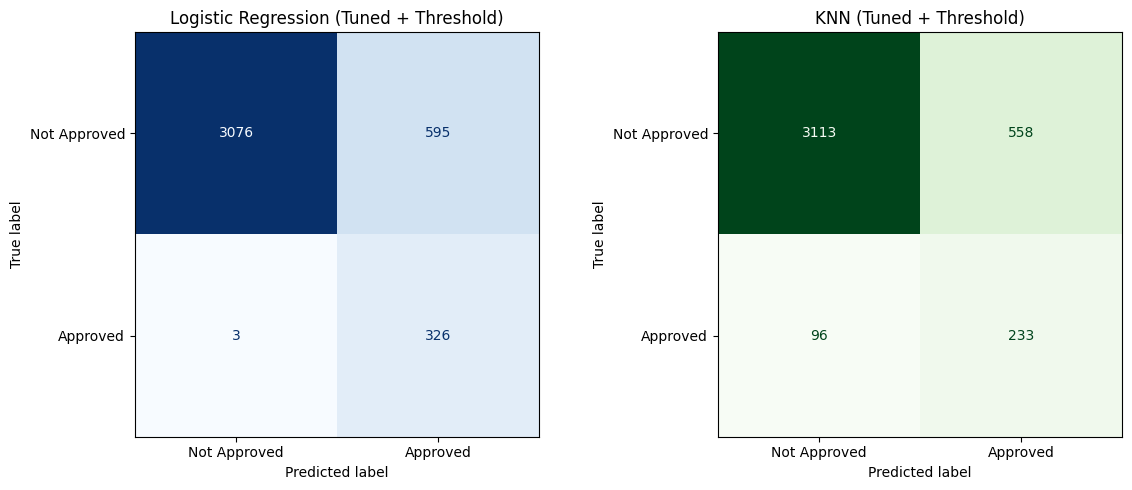

In [ ]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr_best_thresh)
cm_knn = confusion_matrix(y_test, y_pred_knn_best_thresh)

fig, axes = plt.subplots(1,2, figsize=(12,5))

ConfusionMatrixDisplay(cm_lr, display_labels=['Not Approved','Approved']).plot(
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title("Logistic Regression (Tuned + Threshold)")

ConfusionMatrixDisplay(cm_knn, display_labels=['Not Approved','Approved']).plot(
    cmap='Greens', ax=axes[1], colorbar=False
)
axes[1].set_title("KNN (Tuned + Threshold)")

plt.tight_layout()
plt.show()

In [ ]:
# Generate classification reports
report_lr_tuned = classification_report(y_test, y_pred_lr_best_thresh, output_dict=True)
report_knn_tuned = classification_report(y_test, y_pred_knn_best_thresh, output_dict=True)

# Create comparison table
results_df = pd.DataFrame({

    'LR (Tuned)': {
        'Accuracy': report_lr_tuned['accuracy'],
        'Precision': report_lr_tuned['1']['precision'],
        'Recall': report_lr_tuned['1']['recall'],
        'F1-score': report_lr_tuned['1']['f1-score']
    },

    'KNN (Tuned)': {
        'Accuracy': report_knn_tuned['accuracy'],
        'Precision': report_knn_tuned['1']['precision'],
        'Recall': report_knn_tuned['1']['recall'],
        'F1-score': report_knn_tuned['1']['f1-score']
    }

})

results_df = results_df.round(3)
display(results_df)

,LR (Tuned),KNN (Tuned)
Accuracy,0.850,0.836
Precision,0.354,0.295
Recall,0.991,0.708
F1-score,0.522,0.416


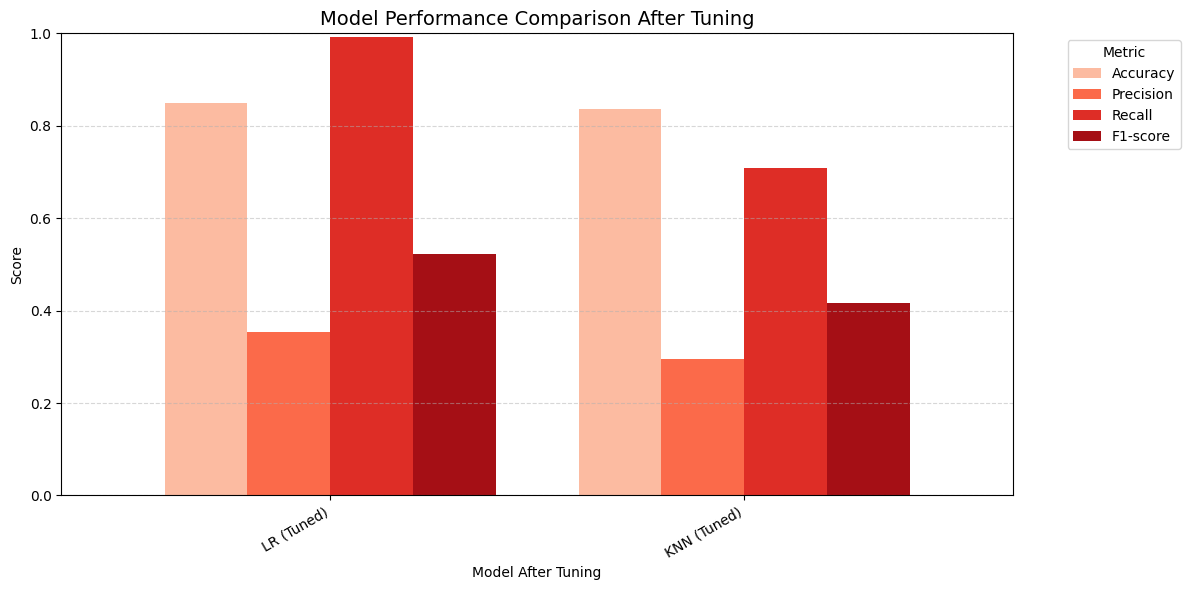

In [ ]:
ax = results_df.T.plot(
    kind='bar',
    figsize=(12,6),
    width=0.8,
    color= ['#fcbba1', '#fb6a4a', '#de2d26', '#a50f15']
)

plt.title("Model Performance Comparison After Tuning", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Model After Tuning")

plt.ylim(0,1)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### **VI. Advanced Models Performance**



#### **1. Random Forest and XGBoost**

#### **a. SMOTE**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest (SMOTE)
rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=None  # SMOTE already balances; so no double-balance
)

# XGBoost (SMOTE)
xgb_smote = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

# Train
xgb_smote.fit(X_train_smote, y_train_smote)
rf_smote.fit(X_train_smote, y_train_smote)

# Predict
y_pred_rf_smote = rf_smote.predict(X_test_imputed)
y_pred_xgb_smote = xgb_smote.predict(X_test_imputed)

# Classification Report
print("Random Forest (Winsorize + KNN Impute + SMOTE)")
print(classification_report(y_test, y_pred_rf_smote))

print("XGBoost (Winsorize + KNN Impute + SMOTE)")
print(classification_report(y_test, y_pred_xgb_smote))

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrices
cm_rf = confusion_matrix(y_test, y_pred_rf_smote)
cm_xgb = confusion_matrix(y_test, y_pred_xgb_smote)

# Create side-by-side layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest — Green
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Greens',
    ax=axes[0],
    values_format='d',
    colorbar=False
)
axes[0].set_title("Random Forest\n(Winsorize + KNN Impute + SMOTE)")

# XGBoost — Purple
ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Purples',
    ax=axes[1],
    values_format='d',
    colorbar=False
)
axes[1].set_title("XGBoost\n(Winsorize + KNN Impute + SMOTE)")

plt.tight_layout()
plt.show()

#### **b. ADASYN**

In [ ]:
# Random Forest (ADASYN)
rf_ada = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=None  # ADASYN already balances; no double-balance
)

# XGBoost (ADASYN)
xgb_ada = XGBClassifier(
    objective="binary:logistic",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

# Train
rf_ada.fit(X_train_ada, y_train_ada)
xgb_ada.fit(X_train_ada, y_train_ada)

# Predict
y_pred_rf_ada = rf_ada.predict(X_test_imputed)
y_pred_xgb_ada = xgb_ada.predict(X_test_imputed)


# Classification Report
print("Random Forest (Winsorize + KNN Impute + ADASYN)")
print(classification_report(y_test, y_pred_rf_ada))

print("XGBoost (Winsorize + KNN Impute + ADASYN)")
print(classification_report(y_test, y_pred_xgb_ada))

In [ ]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf_ada)
cm_xgb = confusion_matrix(y_test, y_pred_xgb_ada)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest — Green
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Greens',
    ax=axes[0],
    values_format='d',
    colorbar=False
)
axes[0].set_title("Random Forest\n(Winsorize + KNN Impute + ADASYN)")

# XGBoost — Purple
ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Purples',
    ax=axes[1],
    values_format='d',
    colorbar=False
)
axes[1].set_title("XGBoost\n(Winsorize + KNN Impute + ADASYN)")

plt.tight_layout()
plt.show()

#### **c. Random Undersampling**

In [21]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest (RUS)
rf_rus = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=None  # RUS already balances
)

# XGBoost (RUS)
xgb_rus = XGBClassifier(
    objective="binary:logistic",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

# Train
rf_rus.fit(X_train_rus, y_train_rus)
xgb_rus.fit(X_train_rus, y_train_rus)

# Predict
y_pred_rf_rus = rf_rus.predict(X_test_imputed)
y_pred_xgb_rus = xgb_rus.predict(X_test_imputed)

# Classification Reports
print("Random Forest (Winsorize + KNN Impute + Random Under-Sampling)")
print(classification_report(y_test, y_pred_rf_rus))

print("XGBoost (Winsorize + KNN Impute + Random Under-Sampling)")
print(classification_report(y_test, y_pred_xgb_rus))

Random Forest (Winsorize + KNN Impute + Random Under-Sampling)
              precision    recall  f1-score   support

           0       1.00      0.83      0.90      3671
           1       0.33      0.96      0.49       329

    accuracy                           0.84      4000
   macro avg       0.66      0.89      0.70      4000
weighted avg       0.94      0.84      0.87      4000

XGBoost (Winsorize + KNN Impute + Random Under-Sampling)
              precision    recall  f1-score   support

           0       1.00      0.83      0.91      3671
           1       0.34      0.96      0.51       329

    accuracy                           0.84      4000
   macro avg       0.67      0.90      0.71      4000
weighted avg       0.94      0.84      0.87      4000



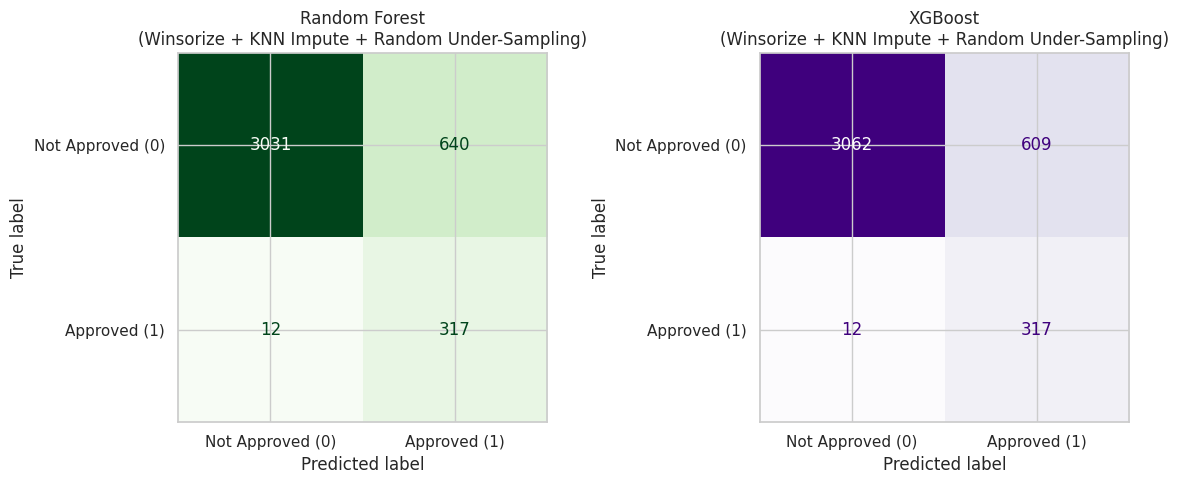

In [22]:
# Confusion Matrices
cm_rf = confusion_matrix(y_test, y_pred_rf_rus)
cm_xgb = confusion_matrix(y_test, y_pred_xgb_rus)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest — Green
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Greens',
    ax=axes[0],
    values_format='d',
    colorbar=False
)
axes[0].set_title("Random Forest\n(Winsorize + KNN Impute + Random Under-Sampling)")

# XGBoost — Purple
ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Purples',
    ax=axes[1],
    values_format='d',
    colorbar=False
)
axes[1].set_title("XGBoost\n(Winsorize + KNN Impute + Random Under-Sampling)")

plt.tight_layout()
plt.show()

#### **d. SMOTE ENN**

In [ ]:
# Random Forest (SMOTEENN)
rf_se = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=None  # SMOTEENN already balances/cleans
)

# XGBoost (SMOTEENN)
xgb_se = XGBClassifier(
    objective="binary:logistic",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

# Train
rf_se.fit(X_train_se, y_train_se)
xgb_se.fit(X_train_se, y_train_se)

# Predict (Original Test Set)
y_pred_rf_se = rf_se.predict(X_test_imputed)
y_pred_xgb_se = xgb_se.predict(X_test_imputed)

# Classification Reports
print("Random Forest (Winsorize + KNN Impute + SMOTE + ENN)")
print(classification_report(y_test, y_pred_rf_se))

print("XGBoost (Winsorize + KNN Impute + SMOTE + ENN)")
print(classification_report(y_test, y_pred_xgb_se))

In [ ]:
# Confusion Matrices
cm_rf = confusion_matrix(y_test, y_pred_rf_se)
cm_xgb = confusion_matrix(y_test, y_pred_xgb_se)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest — Green
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Greens',
    ax=axes[0],
    values_format='d',
    colorbar=False
)
axes[0].set_title("Random Forest\n(Winsorize + KNN Impute + SMOTE + ENN)")

# XGBoost — Purple
ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['Not Approved (0)', 'Approved (1)']
).plot(
    cmap='Purples',
    ax=axes[1],
    values_format='d',
    colorbar=False
)
axes[1].set_title("XGBoost\n(Winsorize + KNN Impute + SMOTE + ENN)")

plt.tight_layout()
plt.show()

#### **2. Methods Comparison**

In [ ]:
report_rf_smote = classification_report(y_test, y_pred_rf_smote, output_dict=True)
report_xgb_smote = classification_report(y_test, y_pred_xgb_smote, output_dict=True)

report_rf_ada = classification_report(y_test, y_pred_rf_ada, output_dict=True)
report_xgb_ada = classification_report(y_test, y_pred_xgb_ada, output_dict=True)

report_rf_rus = classification_report(y_test, y_pred_rf_rus, output_dict=True)
report_xgb_rus = classification_report(y_test, y_pred_xgb_rus, output_dict=True)

report_rf_se = classification_report(y_test, y_pred_rf_se, output_dict=True)
report_xgb_se = classification_report(y_test, y_pred_xgb_se, output_dict=True)

In [ ]:
import pandas as pd

results_rf_xgb = pd.DataFrame({
    'RF (Winsorize + KNN Impute + SMOTE)': {
        'Accuracy': report_rf_smote['accuracy'],
        'Precision': report_rf_smote['1']['precision'],
        'Recall': report_rf_smote['1']['recall'],
        'F1-score': report_rf_smote['1']['f1-score']
    },
    'XGB (Winsorize + KNN Impute + SMOTE)': {
        'Accuracy': report_xgb_smote['accuracy'],
        'Precision': report_xgb_smote['1']['precision'],
        'Recall': report_xgb_smote['1']['recall'],
        'F1-score': report_xgb_smote['1']['f1-score']
    },

    'RF (Winsorize + KNN Impute + ADASYN)': {
        'Accuracy': report_rf_ada['accuracy'],
        'Precision': report_rf_ada['1']['precision'],
        'Recall': report_rf_ada['1']['recall'],
        'F1-score': report_rf_ada['1']['f1-score']
    },
    'XGB (Winsorize + KNN Impute + ADASYN)': {
        'Accuracy': report_xgb_ada['accuracy'],
        'Precision': report_xgb_ada['1']['precision'],
        'Recall': report_xgb_ada['1']['recall'],
        'F1-score': report_xgb_ada['1']['f1-score']
    },

    'RF (Winsorize + KNN Impute + Random Under-Sampling)': {
        'Accuracy': report_rf_rus['accuracy'],
        'Precision': report_rf_rus['1']['precision'],
        'Recall': report_rf_rus['1']['recall'],
        'F1-score': report_rf_rus['1']['f1-score']
    },
    'XGB (Winsorize + KNN Impute + Random Under-Sampling)': {
        'Accuracy': report_xgb_rus['accuracy'],
        'Precision': report_xgb_rus['1']['precision'],
        'Recall': report_xgb_rus['1']['recall'],
        'F1-score': report_xgb_rus['1']['f1-score']
    },

    'RF (Winsorize + KNN Impute + SMOTE + ENN)': {
        'Accuracy': report_rf_se['accuracy'],
        'Precision': report_rf_se['1']['precision'],
        'Recall': report_rf_se['1']['recall'],
        'F1-score': report_rf_se['1']['f1-score']
    },
    'XGB (Winsorize + KNN Impute + SMOTE + ENN)': {
        'Accuracy': report_xgb_se['accuracy'],
        'Precision': report_xgb_se['1']['precision'],
        'Recall': report_xgb_se['1']['recall'],
        'F1-score': report_xgb_se['1']['f1-score']
    }
})

results_rf_xgb = results_rf_xgb.round(3)
results_rf_xgb

In [ ]:
import matplotlib.pyplot as plt

ax = results_df.T.plot(
    kind='bar',
    figsize=(12, 6),
    width=0.8,
    color = ['#fde0dd', '#fa9fb5', '#f768a1', '#c51b8a']
)

plt.title("Advance Models Performance Comparison Across All Methods", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Model & Imputation Method")
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **VII. XGBoost and Random Forest with Hyperparameter**

#### **a. XGBoost (Tuned)**

In [23]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
import numpy as np

# Compute class weight from ORIGINAL training labels
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Base model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

# Grid search
grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit on ORIGINAL imputed training data
grid_xgb.fit(X_train_imputed, y_train)

# Best model
best_xgb = grid_xgb.best_estimator_

print("Best XGBoost Parameters:")
print(grid_xgb.best_params_)
print("Best XGBoost CV F1-score:", grid_xgb.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best XGBoost Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 400, 'subsample': 0.8}
Best XGBoost CV F1-score: 0.5093606741025417


In [24]:
y_pred_best_xgb = best_xgb.predict(X_test_imputed)

print("XGBoost (Tuned, default threshold = 0.5)")
print(classification_report(y_test, y_pred_best_xgb))

XGBoost (Tuned, default threshold = 0.5)
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      3671
           1       0.35      0.94      0.51       329

    accuracy                           0.85      4000
   macro avg       0.67      0.89      0.71      4000
weighted avg       0.94      0.85      0.88      4000



In [25]:
from sklearn.metrics import classification_report, f1_score
import numpy as np
import pandas as pd

# Predicted probabilities for class 1
y_prob_xgb = best_xgb.predict_proba(X_test_imputed)[:, 1]

thresholds = np.arange(0.30, 0.81, 0.05)

threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    threshold_results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t, zero_division=0),
        'F1-score': f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df = threshold_df.round(3)
display(threshold_df)

best_row = threshold_df.loc[threshold_df['F1-score'].idxmax()]
best_threshold = best_row['Threshold']

print("Best threshold for F1:", best_threshold)
print("Best threshold row:")
print(best_row)

,Threshold,Precision,Recall,F1-score
0,0.30,0.344,0.982,0.509
1,0.35,0.344,0.970,0.508
2,0.40,0.344,0.960,0.506
3,0.45,0.349,0.957,0.512
4,0.50,0.349,0.939,0.509
5,0.55,0.350,0.927,0.508
6,0.60,0.352,0.915,0.508
7,0.65,0.354,0.884,0.506
8,0.70,0.346,0.799,0.483
9,0.75,0.346,0.705,0.464


Best threshold for F1: 0.45
Best threshold row:
Threshold    0.450
Precision    0.349
Recall       0.957
F1-score     0.512
Name: 3, dtype: float64


In [26]:
y_pred_xgb_best_thresh = (y_prob_xgb >= best_threshold).astype(int)

print(f"XGBoost (Tuned, threshold = {best_threshold})")
print(classification_report(y_test, y_pred_xgb_best_thresh))

XGBoost (Tuned, threshold = 0.45)
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      3671
           1       0.35      0.96      0.51       329

    accuracy                           0.85      4000
   macro avg       0.67      0.90      0.71      4000
weighted avg       0.94      0.85      0.88      4000



#### **b. Random Forest (Tuned)**

In [27]:
# Parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Base model
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Grid search
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit on RUS-balanced training set
grid_rf.fit(X_train_rus, y_train_rus)

# Best model
best_rf = grid_rf.best_estimator_

print("Best Random Forest Parameters:")
print(grid_rf.best_params_)
print("Best Random Forest CV F1-score:", grid_rf.best_score_)

Best Random Forest Parameters:
{'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Random Forest CV F1-score: 0.9099780270909268


In [28]:
# Predict
y_pred_best_rf = best_rf.predict(X_test_imputed)

# Classification Report
print("Random Forest (Tuned)")
print(classification_report(y_test, y_pred_best_rf))

Random Forest (Tuned)
              precision    recall  f1-score   support

           0       1.00      0.82      0.90      3671
           1       0.33      0.96      0.49       329

    accuracy                           0.84      4000
   macro avg       0.66      0.89      0.70      4000
weighted avg       0.94      0.84      0.87      4000



#### **c. Methods Comparison**

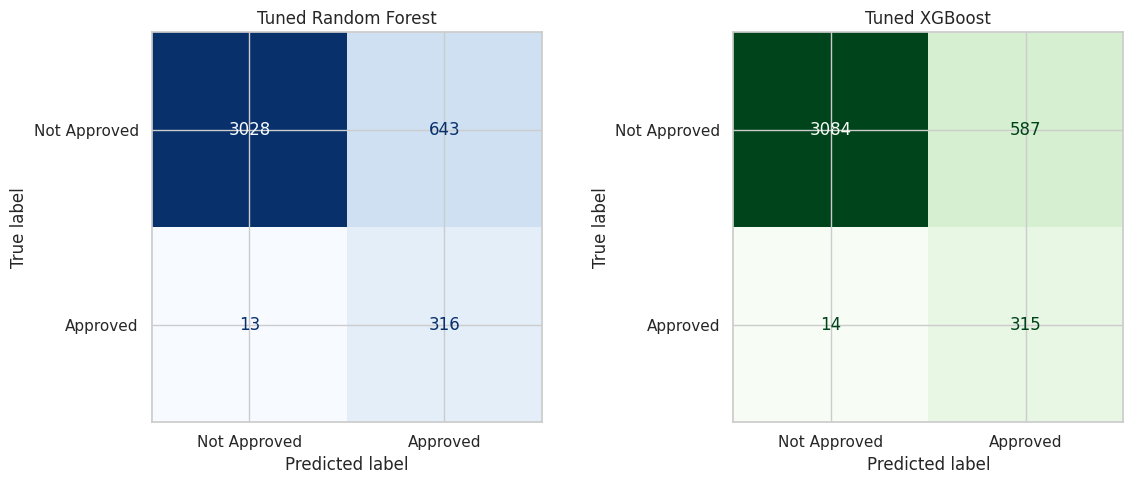

In [29]:
# Confusion Matrix
cm_rf_tuned = confusion_matrix(y_test, y_pred_best_rf)
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_best_thresh)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest (Tuned)
ConfusionMatrixDisplay(
    cm_rf_tuned,
    display_labels=['Not Approved', 'Approved']
).plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title("Tuned Random Forest")

# XGBoost (Tuned)
ConfusionMatrixDisplay(
    cm_xgb_tuned,
    display_labels=['Not Approved', 'Approved']
).plot(cmap='Greens', ax=axes[1], colorbar=False)
axes[1].set_title("Tuned XGBoost")

plt.tight_layout()
plt.show()

In [30]:
# Table
report_rf_tuned = classification_report(y_test, y_pred_best_rf, output_dict=True)
report_xgb_tuned = classification_report(y_test, y_pred_xgb_best_thresh, output_dict=True)

results_adv_df = pd.DataFrame({
    'RF (Tuned)': {
        'Accuracy': report_rf_tuned['accuracy'],
        'Precision': report_rf_tuned['1']['precision'],
        'Recall': report_rf_tuned['1']['recall'],
        'F1-score': report_rf_tuned['1']['f1-score']
    },
    'XGB (Tuned)': {
        'Accuracy': report_xgb_tuned['accuracy'],
        'Precision': report_xgb_tuned['1']['precision'],
        'Recall': report_xgb_tuned['1']['recall'],
        'F1-score': report_xgb_tuned['1']['f1-score']
    }
})

results_adv_df = results_adv_df.round(3)
results_adv_df

,RF (Tuned),XGB (Tuned)
Accuracy,0.836,0.850
Precision,0.330,0.349
Recall,0.960,0.957
F1-score,0.491,0.512


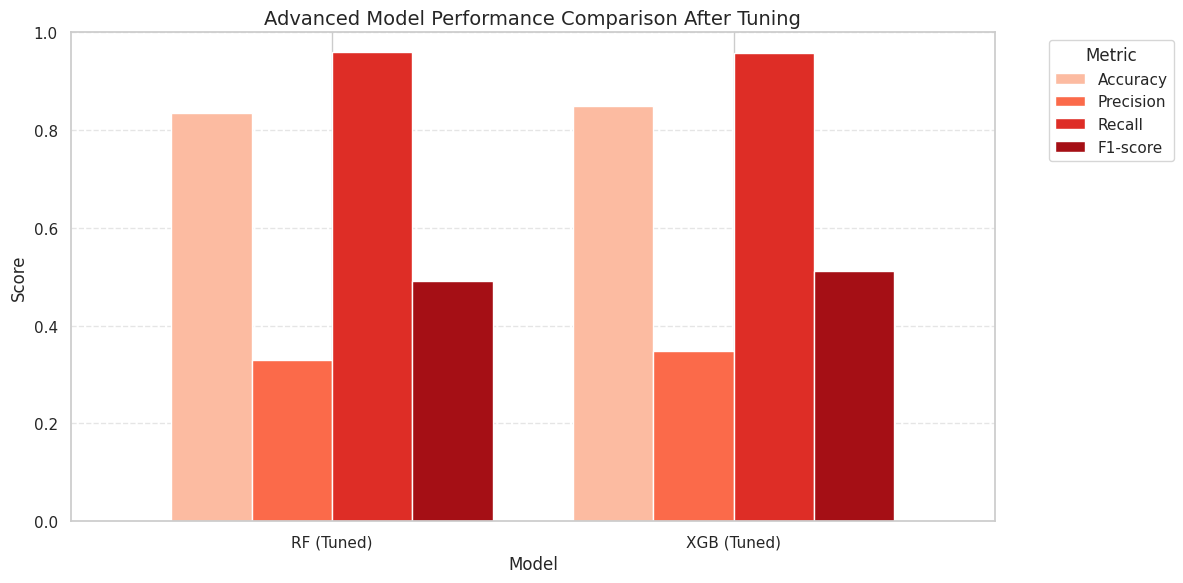

In [31]:
# Bar Chart
ax = results_adv_df.T.plot(
    kind='bar',
    figsize=(12, 6),
    width=0.8,
    color=['#fcbba1', '#fb6a4a', '#de2d26', '#a50f15']
)

plt.title("Advanced Model Performance Comparison After Tuning", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **VIII. Explainable AI**

#### **1. Global Model Explanation**

#### **a. Install SHAP**

In [32]:
import shap

#### **b. Convert imputed arrays back to DataFrame**

In [33]:
feature_names = X.columns.tolist()

X_train_imputed_df = pd.DataFrame(X_train_imputed, columns=feature_names)
X_test_imputed_df = pd.DataFrame(X_test_imputed, columns=feature_names)

#### **c. SHAP global explanation for XGBoost**

 99%|===================| 3957/4000 [00:18<00:00]        

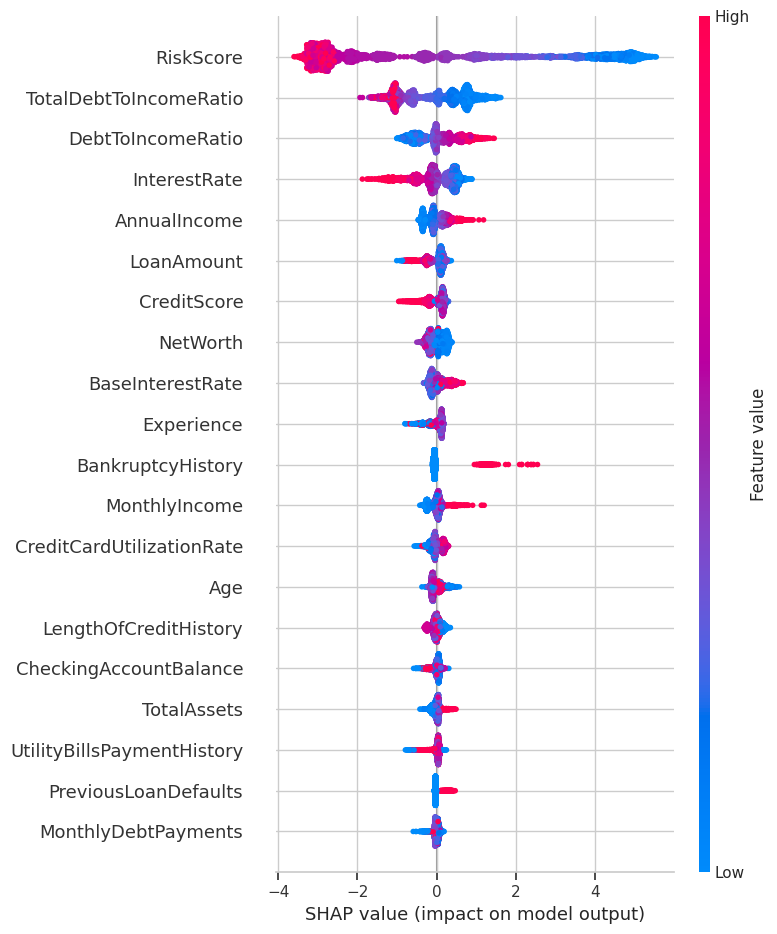

In [34]:
# Create SHAP explainer
explainer_xgb = shap.Explainer(best_xgb, X_train_imputed_df)

# Compute SHAP values on test set
shap_values_xgb = explainer_xgb(X_test_imputed_df)

# Global summary plot
shap.summary_plot(shap_values_xgb, X_test_imputed_df)

#### **d. Mean absolute SHAP importance table**

In [35]:
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_ABS_SHAP': np.abs(shap_values_xgb.values).mean(axis=0)
}).sort_values(by='Mean_ABS_SHAP', ascending=False)

shap_importance.head(10)

,Feature,Mean_ABS_SHAP
28,RiskScore,2.672958
27,TotalDebtToIncomeRatio,0.741870
11,DebtToIncomeRatio,0.420912
25,InterestRate,0.391932
1,AnnualIncome,0.219959
4,LoanAmount,0.173612
2,CreditScore,0.171042
23,NetWorth,0.165977
24,BaseInterestRate,0.155916
3,Experience,0.134409


#### **e. Bar plot of top 10 most important features**

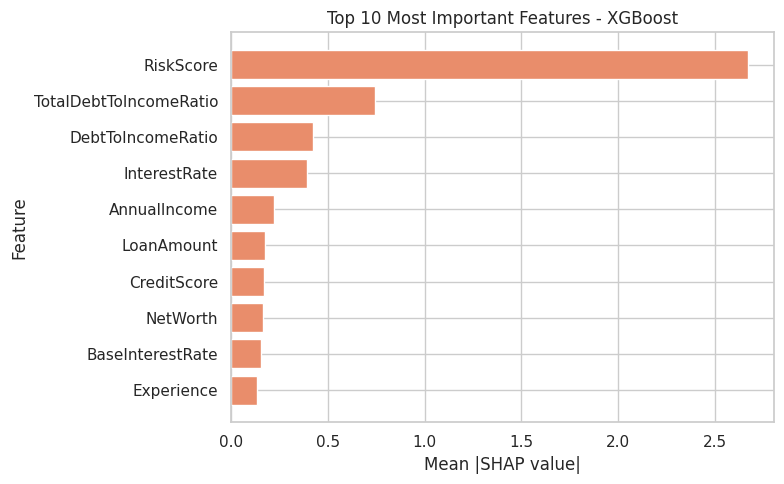

In [36]:
top10_shap = shap_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10_shap['Feature'][::-1], top10_shap['Mean_ABS_SHAP'][::-1])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features - XGBoost")
plt.tight_layout()
plt.show()

#### **2. Local Model Explanation**

#### **a. Test case example**

In [37]:
sample_index = 0

# Print prediction info
print("True label:", y_test.iloc[sample_index])
print("Predicted probability:", y_prob_xgb[sample_index])
print("Predicted label:", y_pred_xgb_best_thresh[sample_index])

# Convert row to vertical table
sample_vertical = X_test_imputed_df.iloc[[sample_index]].T
sample_vertical.columns = ["Value"]

sample_vertical

True label: 0
Predicted probability: 0.00022882236
Predicted label: 0


,Value
Age,-0.063160
AnnualIncome,-0.956184
CreditScore,-0.362424
Experience,-0.132944
LoanAmount,-1.132111
LoanDuration,0.238437
NumberOfDependents,-0.369926
MonthlyDebtPayments,2.001264
CreditCardUtilizationRate,-0.467948
NumberOfOpenCreditLines,-0.005778


#### **b. Waterfall Plot for one prediction**

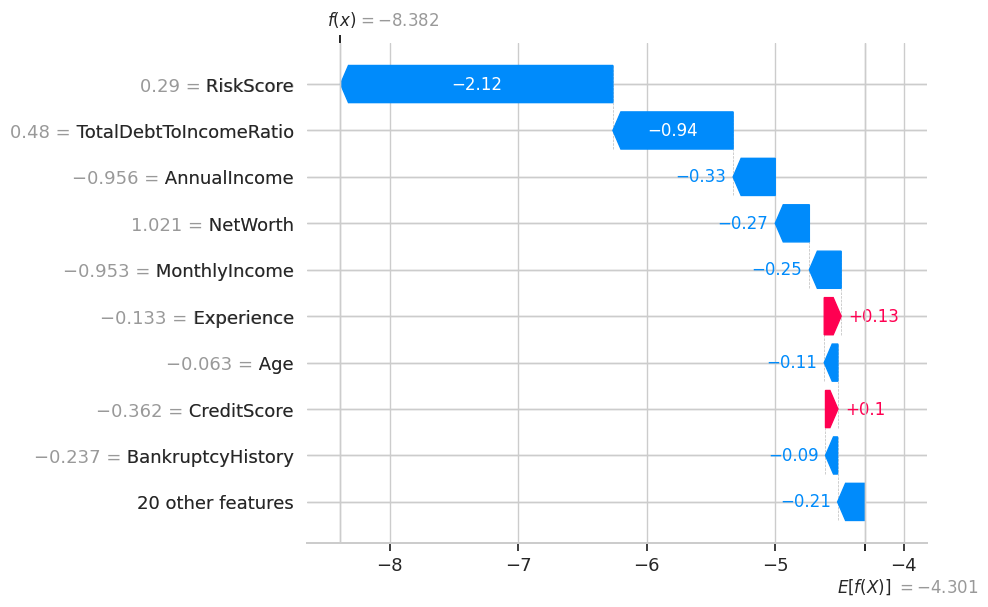

In [38]:
shap.plots.waterfall(shap_values_xgb[sample_index])

#### **c. Force Plot**

In [39]:
shap.initjs()
shap.plots.force(shap_values_xgb[sample_index])

#### **Download for Streamlit**

In [55]:
import joblib

# MODEL + PREPROCESSING
joblib.dump(best_xgb, "best_xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(knn_imputer, "imputer.pkl")
joblib.dump(iqr_caps, "iqr_caps.pkl")
joblib.dump(X.columns.tolist(), "feature_names.pkl")
joblib.dump(best_threshold, "best_threshold.pkl")

# METRICS
joblib.dump(results_adv_df.reset_index().rename(columns={'index':'Metric'}), "metrics_df.pkl")

# DATA FOR SHAP
joblib.dump(X_train_imputed_df, "X_train_imputed_df.pkl")
joblib.dump(X_test_imputed_df, "X_test_imputed_df.pkl")

# SHAP VALUES
joblib.dump(shap_values_xgb, "shap_values_test.pkl")

print("All files saved successfully!")

All files saved successfully!


In [57]:
import pandas as pd
import joblib

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [
        report_xgb_tuned["accuracy"],
        report_xgb_tuned["1"]["precision"],
        report_xgb_tuned["1"]["recall"],
        report_xgb_tuned["1"]["f1-score"],
    ]
})

joblib.dump(metrics_df, "metrics_df.pkl")

print(metrics_df)

      Metric     Value
0   Accuracy  0.849750
1  Precision  0.349224
2     Recall  0.957447
3   F1-score  0.511779


In [56]:
import os
os.listdir()

['Loan_Approval_Final_8.csv',
 'feature_names.pkl',
 'best_xgb_model.pkl',
 'Loan_Approval_Prediction.ipynb',
 'best_threshold.pkl',
 'shap_values_test.pkl',
 'X_train_imputed_df.pkl',
 'scaler.pkl',
 'iqr_caps.pkl',
 '.ipynb_checkpoints',
 'metrics_df.pkl',
 'imputer.pkl',
 'X_test_imputed_df.pkl']